In [317]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt

## Load Data
### Base Path

In [318]:
base_path = "../data/Sample_Game_1/"


### Load Events

In [319]:
events = pd.read_csv(base_path + "Sample_Game_1_RawEventsData.csv")
events.head()

,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y
0,Away,SET PIECE,KICK OFF,1,1,0.04,0,0.00,Player19,NaN,NaN,NaN,NaN,NaN
1,Away,PASS,NaN,1,1,0.04,3,0.12,Player19,Player21,0.45,0.39,0.55,0.43
2,Away,PASS,NaN,1,3,0.12,17,0.68,Player21,Player15,0.55,0.43,0.58,0.21
3,Away,PASS,NaN,1,45,1.80,61,2.44,Player15,Player19,0.55,0.19,0.45,0.31
4,Away,PASS,NaN,1,77,3.08,96,3.84,Player19,Player21,0.45,0.32,0.49,0.47


### Load Tracking (Home)

In [320]:
tracking_home = pd.read_csv(
    base_path + "Sample_Game_1_RawTrackingData_Home_Team.csv"
)

tracking_home.head()

C:\Users\30697\AppData\Local\Temp\ipykernel_10760\1918793147.py:1: DtypeWarning: Columns (0,1,2,3,5,7,9,11,13,15,17,19,21,23,25,27,29,31) have mixed types. Specify dtype option on import or set low_memory=False.
  tracking_home = pd.read_csv(


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Home,Unnamed: 4,Home.1,Unnamed: 6,Home.2,Unnamed: 8,Home.3,...,Home.10,Unnamed: 24,Home.11,Unnamed: 26,Home.12,Unnamed: 28,Home.13,Unnamed: 30,Unnamed: 31,Unnamed: 32
0,NaN,NaN,NaN,11,NaN,1,NaN,2,NaN,3,...,10,NaN,12,NaN,13,NaN,14,NaN,NaN,NaN
1,Period,Frame,Time [s],Player11,NaN,Player1,NaN,Player2,NaN,Player3,...,Player10,NaN,Player12,NaN,Player13,NaN,Player14,NaN,Ball,NaN
2,1,1,0.04,0.00082,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.45472,0.38709
3,1,2,0.08,0.00096,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.49645,0.40656
4,1,3,0.12,0.00114,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.53716,0.42556


### Load Tracking (Away)

In [321]:
tracking_away = pd.read_csv(
    base_path + "Sample_Game_1_RawTrackingData_Away_Team.csv"
)

tracking_away.head()

C:\Users\30697\AppData\Local\Temp\ipykernel_10760\3652936359.py:1: DtypeWarning: Columns (0,1,2,3,5,7,9,11,13,15,17,19,21,23,25,27,29,31) have mixed types. Specify dtype option on import or set low_memory=False.
  tracking_away = pd.read_csv(


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Away,Unnamed: 4,Away.1,Unnamed: 6,Away.2,Unnamed: 8,Away.3,...,Away.10,Unnamed: 24,Away.11,Unnamed: 26,Away.12,Unnamed: 28,Away.13,Unnamed: 30,Away.14,Unnamed: 32
0,NaN,NaN,NaN,25,NaN,15,NaN,16,NaN,17,...,24,NaN,26,NaN,27,NaN,28,NaN,NaN,NaN
1,Period,Frame,Time [s],Player25,NaN,Player15,NaN,Player16,NaN,Player17,...,Player24,NaN,Player26,NaN,Player27,NaN,Player28,NaN,Ball,NaN
2,1,1,0.04,0.90509,0.47462,0.58393,0.20794,0.67658,0.4671,0.6731,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.45472,0.38709
3,1,2,0.08,0.90494,0.47462,0.58393,0.20794,0.67658,0.4671,0.6731,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.49645,0.40656
4,1,3,0.12,0.90434,0.47463,0.58393,0.20794,0.67658,0.4671,0.6731,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.53716,0.42556


## Data Familiarization

### Shape of each dataset

In [322]:
print("Events shape:", events.shape)
print("Home tracking shape:", tracking_home.shape)
print("Away tracking shape:", tracking_away.shape)

Events shape: (1745, 14)
Home tracking shape: (145008, 33)
Away tracking shape: (145008, 33)


### Events
#### Columns & summary table

In [323]:
events.columns

Index(['Team', 'Type', 'Subtype', 'Period', 'Start Frame', 'Start Time [s]',
       'End Frame', 'End Time [s]', 'From', 'To', 'Start X', 'Start Y',
       'End X', 'End Y'],
      dtype='object')

In [324]:
events.info()
events.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1745 entries, 0 to 1744
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Team            1745 non-null   object 
 1   Type            1745 non-null   object 
 2   Subtype         792 non-null    object 
 3   Period          1745 non-null   int64  
 4   Start Frame     1745 non-null   int64  
 5   Start Time [s]  1745 non-null   float64
 6   End Frame       1745 non-null   int64  
 7   End Time [s]    1745 non-null   float64
 8   From            1745 non-null   object 
 9   To              799 non-null    object 
 10  Start X         1664 non-null   float64
 11  Start Y         1664 non-null   float64
 12  End X           1109 non-null   float64
 13  End Y           1109 non-null   float64
dtypes: float64(6), int64(3), object(5)
memory usage: 191.0+ KB


,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y
count,1745,1745,792,1745.000000,1745.000000,1745.000000,1745.000000,1745.000000,1745,799,1664.000000,1664.000000,1109.000000,1109.000000
unique,2,9,51,NaN,NaN,NaN,NaN,NaN,28,28,NaN,NaN,NaN,NaN
top,Home,PASS,INTERCEPTION,NaN,NaN,NaN,NaN,NaN,Player19,Player21,NaN,NaN,NaN,NaN
freq,917,799,290,NaN,NaN,NaN,NaN,NaN,103,69,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,1.488825,70503.382235,2820.135289,70526.925501,2821.077020,NaN,NaN,0.527139,0.502524,0.524454,0.503201
std,NaN,NaN,NaN,0.500018,41925.812208,1677.032488,41925.545286,1677.021811,NaN,NaN,0.243625,0.283635,0.242372,0.299590
min,NaN,NaN,NaN,1.000000,1.000000,0.040000,0.000000,0.000000,NaN,NaN,0.000000,-0.020000,-0.050000,-0.040000
25%,NaN,NaN,NaN,1.000000,32338.000000,1293.520000,32338.000000,1293.520000,NaN,NaN,0.360000,0.270000,0.350000,0.250000
50%,NaN,NaN,NaN,1.000000,68920.000000,2756.800000,68945.000000,2757.800000,NaN,NaN,0.530000,0.490000,0.530000,0.490000
75%,NaN,NaN,NaN,2.000000,107787.000000,4311.480000,107802.000000,4312.080000,NaN,NaN,0.702500,0.752500,0.690000,0.780000


#### Basic Info

The events dataset contains 1,745 annotated match events across two teams and two match periods.
Passes dominate the event distribution (~X%), which aligns with expected football match dynamics.
The presence of 51 unique subtypes suggests fine-grained event categorization (e.g., interceptions, clearances, etc.).
Missing values in spatial columns (Start X/Y, End X/Y) indicate that not all events are spatially defined (e.g., fouls, offsides), which will require conditional handling during spatial analysis.

#### Frames Analysis

The relationship between frame index and time usually is:

$$
\text{Time (seconds)} = \frac{\text{Frame}}{25}
$$

Equivalently:

$$
\text{Frame} = 25 \times \text{Time (seconds)}
$$

In [325]:
# Check frame theory for start and end times
events_frames=events[['Start Frame', 'End Frame','Start Time [s]','End Time [s]']].copy()
# Calculate time deriving from frame number (assuming 25 fps)
events_frames['Computed_Time_from_Frame_Start'] = events_frames['Start Frame'] / 25
events_frames['Computed_Time_from_Frame_End'] = events_frames['End Frame'] / 25

# Difference between computed time and actual start time
events_frames['Start_Time_Diff'] = (
    events_frames['Computed_Time_from_Frame_Start'] - events_frames['Start Time [s]']
)
events_frames['End_Time_Diff'] = (
    events_frames['Computed_Time_from_Frame_End'] - events_frames['End Time [s]']
)

# Max absolute difference

print("Max absolute difference:",
      events_frames['Start_Time_Diff'].abs().max()) # Should be close to zero if frame theory holds
print("Max absolute difference (End Time):",events_frames['End_Time_Diff'].abs().max())

events_frames[['Start Frame', 'Start Time [s]','End Frame', 'End Time [s]',
        'Computed_Time_from_Frame_Start', 'Computed_Time_from_Frame_End', 'Start_Time_Diff', 'End_Time_Diff']].head()

Max absolute difference: 0.0
Max absolute difference (End Time): 0.0


,Start Frame,Start Time [s],End Frame,End Time [s],Computed_Time_from_Frame_Start,Computed_Time_from_Frame_End,Start_Time_Diff,End_Time_Diff
0,1,0.04,0,0.00,0.04,0.00,0.0,0.0
1,1,0.04,3,0.12,0.04,0.12,0.0,0.0
2,3,0.12,17,0.68,0.12,0.68,0.0,0.0
3,45,1.80,61,2.44,1.80,2.44,0.0,0.0
4,77,3.08,96,3.84,3.08,3.84,0.0,0.0


### Univariate Categorical Distribution Analysis



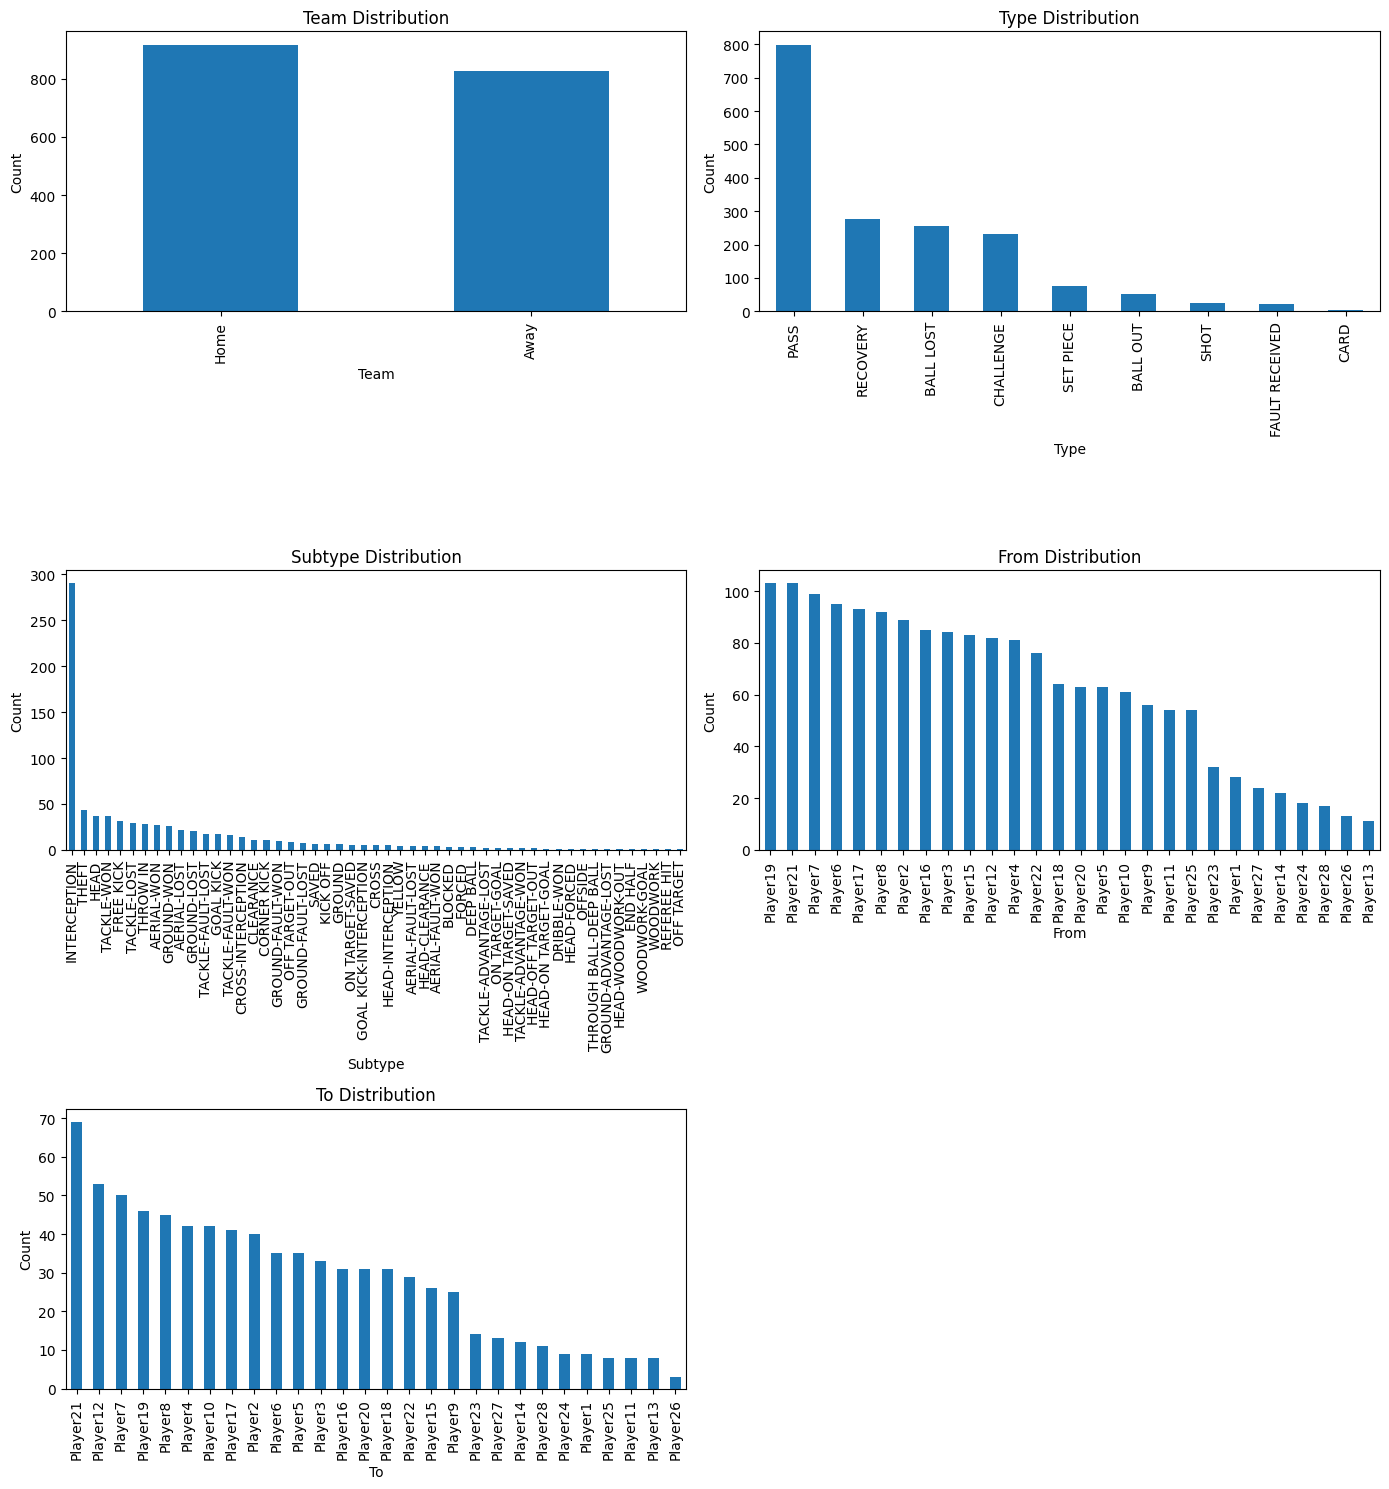

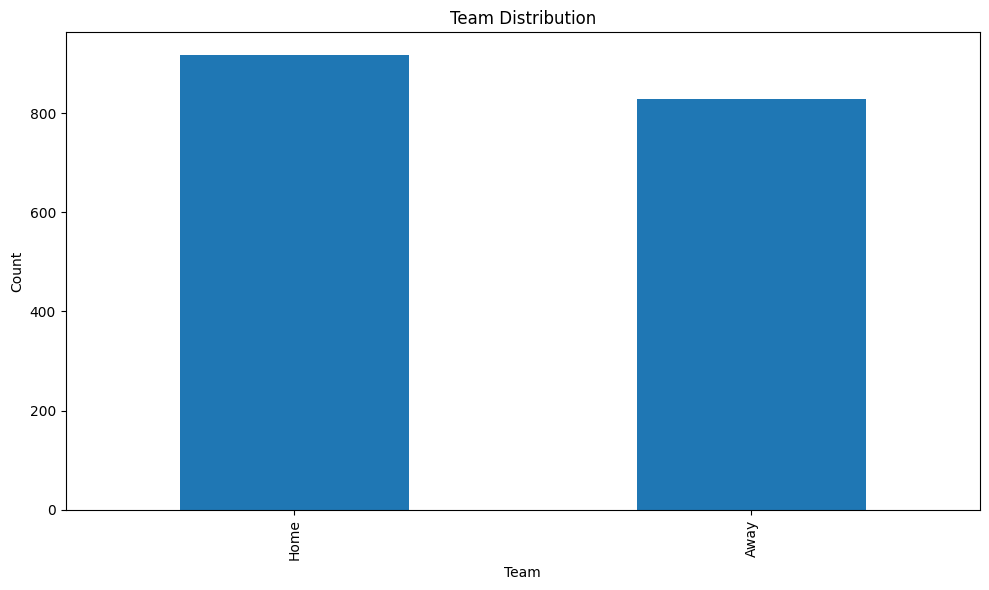

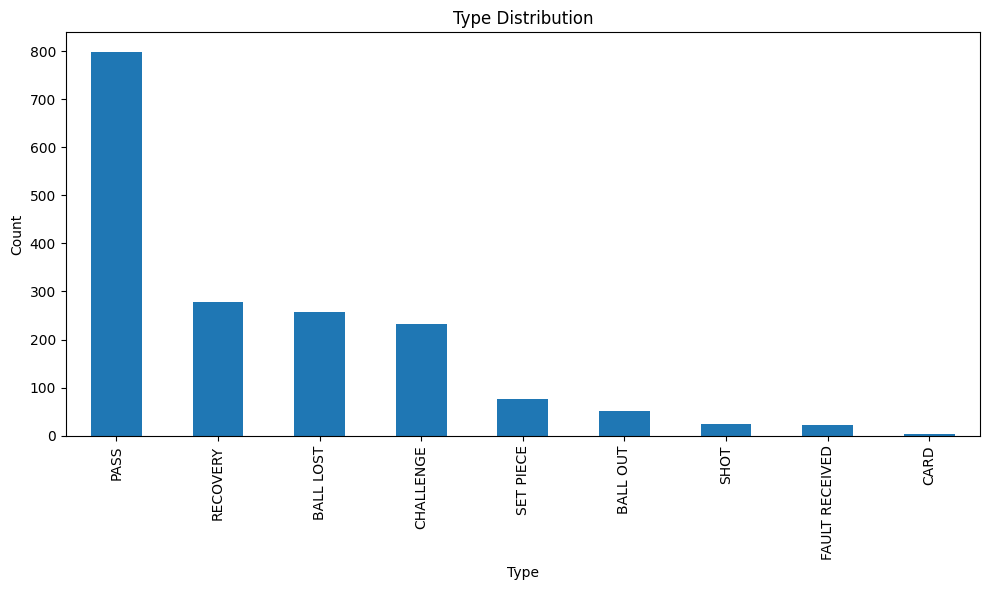

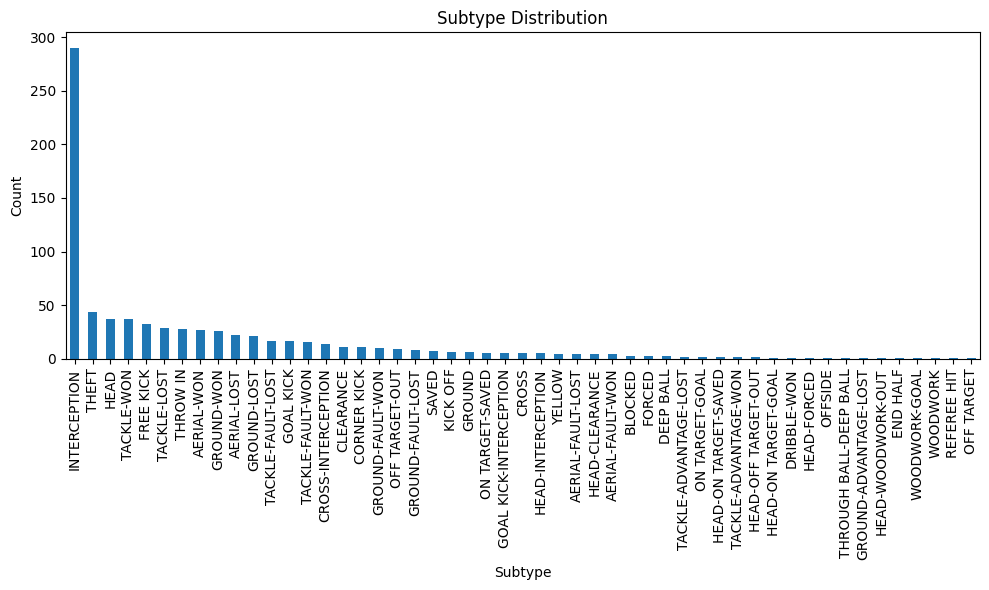

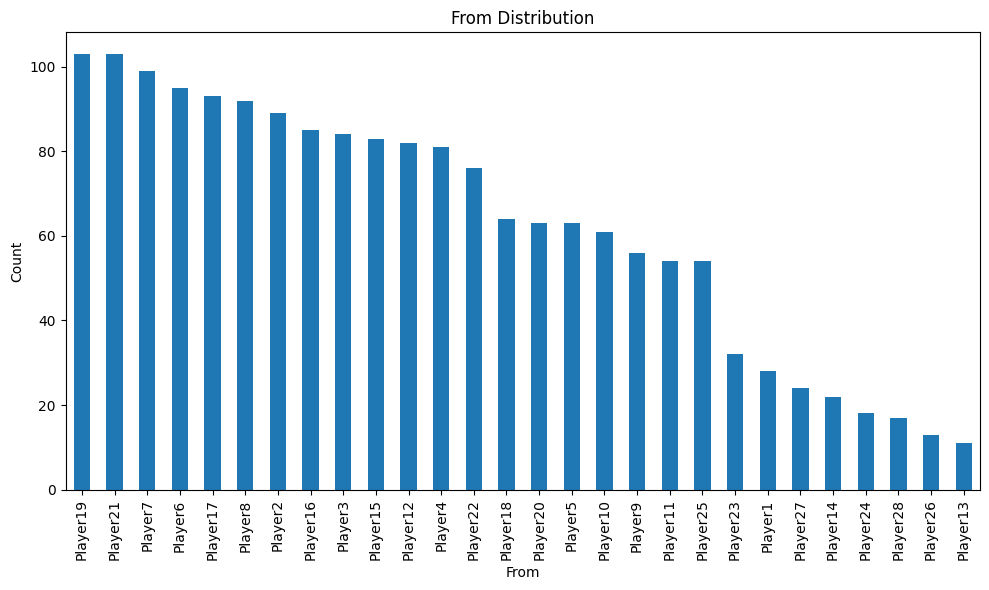

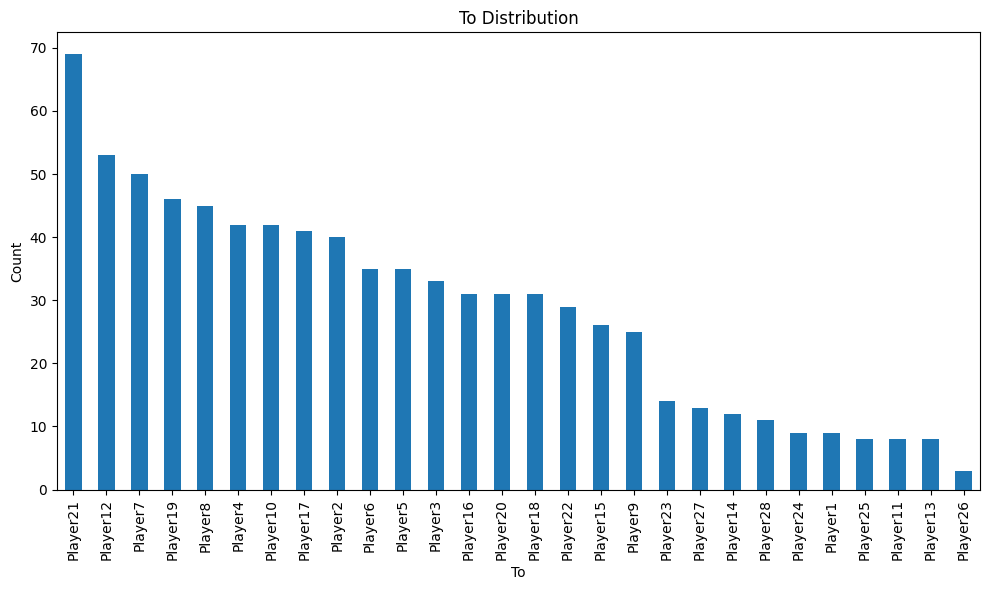

In [326]:
# Select categorical columns
cat_cols = events.select_dtypes(include=['object', 'category']).columns

n_cols = 2  
n_rows = int(np.ceil(len(cat_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = events[col].value_counts().sort_values(ascending=False)
    counts.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Remove unused subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# and one by one
for col in cat_cols:
    plt.figure(figsize=(10, 6))
    events[col].value_counts().sort_values(ascending=False).plot(kind='bar')
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

### 🏠 Team Distribution

- Roughly balanced Home vs Away  
- Good dataset balance for modeling  
- No major sampling bias  


### ⚽ Type Distribution

- PASS dominates heavily  
- Dataset is event-heavy on ball movement  
- Strong class imbalance (important for ML models)  


### 🔍 Subtype Distribution

- Very long tail distribution  
- Many rare event types  
- Likely need grouping or dimensionality reduction  
- Possible feature engineering opportunity  


### 👤 From Distribution

- Some players heavily involved  
- Identify key playmakers  
- Detect central players in the network  


### 🎯 To Distribution

- Passing targets distribution  
- Can build passing network graphs  
- Useful for tactical analysis  

### Data integrity / structural validation

In [327]:
home_players = set(events[events['Team'] == 'Home']['From'].unique())
away_players = set(events[events['Team'] == 'Away']['From'].unique())

# Check for players appearing in both teams (should be 0 if data is correct)
len(home_players.intersection(away_players))

0

No players overlap !

Check for Players Who Only Initiate

That would mean they initiate actions but never receive — which could indicate:

1)Data entry error

2)Missing rows

3)Filtering issues

4)Or just tactical reality (e.g., goalkeeper long balls)

In [328]:
from_players = set(events['From'].unique())
to_players = set(events['To'].unique())

only_initiators = from_players - to_players

only_initiators

set()

Same for only receivers

In [329]:
only_receivers = to_players - from_players

only_receivers

{nan}

### Missing Values

#### Check missing values for column To

Some events have:

To == NaN

That is completely normal in football event data for things like:

Shots

Clearances

Fouls

Ball out

Cards

Some duels

Those actions don't have a receiving player.

So this is not a structural network problem — it’s probably a data completeness issue but we should check this.

In [330]:
events[events['To'].isna()]['Type'].value_counts()

Type
RECOVERY          278
BALL LOST         257
CHALLENGE         233
SET PIECE          77
BALL OUT           51
SHOT               24
FAULT RECEIVED     22
CARD                4
Name: count, dtype: int64

#### We apply same logic for subtypes that also have missing values

In [331]:
events[events['Subtype'].isna()]['Type'].value_counts()

Type
PASS              757
RECOVERY           84
BALL LOST          51
BALL OUT           39
FAULT RECEIVED     22
Name: count, dtype: int64

#### Check PASS Subtype Coverage Rate

If ~90% are NaN → subtype probably not consistently recorded

If ~20% are NaN → maybe only special passes get subtypes

If ~100% are NaN → subtype field may be unused for passes

In [332]:
pass_events = events[events['Type'] == 'PASS']

pass_events['Subtype'].isna().mean() 

np.float64(0.9474342928660826)

In [333]:
pass_events['Subtype'].value_counts()

Subtype
HEAD                      20
GOAL KICK                 13
CROSS                      3
DEEP BALL                  2
HEAD-CLEARANCE             2
THROUGH BALL-DEEP BALL     1
CLEARANCE                  1
Name: count, dtype: int64

#### We should do this for all subtypes

In [334]:
events.groupby('Type')['Subtype'].apply(lambda x: x.isna().mean()).sort_values(ascending=False)

Type
FAULT RECEIVED    1.000000
PASS              0.947434
BALL OUT          0.764706
RECOVERY          0.302158
BALL LOST         0.198444
CHALLENGE         0.000000
CARD              0.000000
SET PIECE         0.000000
SHOT              0.000000
Name: Subtype, dtype: float64

3 groups appear:
1️⃣ Types where subtype is optional

PASS

BALL OUT

RECOVERY

BALL LOST

These are general events where subtype adds extra detail but is not required.

2️⃣ Types where subtype is mandatory

SHOT

SET PIECE

CARD

CHALLENGE

These events are defined by their subtype, so they always have one.

Example:

SHOT
 ├ HEAD
 ├ VOLLEY
 ├ FREE KICK

 
3️⃣ Types where subtype may not exist

FAULT RECEIVED

#### Create new subtype clean with filled subtypes

In [335]:
events['Subtype_clean'] = events['Subtype']

In [336]:
events.head()

,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y,Subtype_clean
0,Away,SET PIECE,KICK OFF,1,1,0.04,0,0.00,Player19,NaN,NaN,NaN,NaN,NaN,KICK OFF
1,Away,PASS,NaN,1,1,0.04,3,0.12,Player19,Player21,0.45,0.39,0.55,0.43,NaN
2,Away,PASS,NaN,1,3,0.12,17,0.68,Player21,Player15,0.55,0.43,0.58,0.21,NaN
3,Away,PASS,NaN,1,45,1.80,61,2.44,Player15,Player19,0.55,0.19,0.45,0.31,NaN
4,Away,PASS,NaN,1,77,3.08,96,3.84,Player19,Player21,0.45,0.32,0.49,0.47,NaN


In [337]:
events.loc[
    (events['Type'] == 'PASS') & (events['Subtype_clean'].isna()),
    'Subtype_clean'
] = 'NORMAL PASS'

In [338]:
events.loc[
    (events['Subtype_clean'].isna()),
    'Subtype_clean'
] = events['Type']

#### Check again for missing in the new column

In [339]:
events.groupby('Type')['Subtype_clean'].apply(lambda x: x.isna().mean()).sort_values(ascending=False)

Type
BALL LOST         0.0
BALL OUT          0.0
CARD              0.0
CHALLENGE         0.0
FAULT RECEIVED    0.0
PASS              0.0
RECOVERY          0.0
SET PIECE         0.0
SHOT              0.0
Name: Subtype_clean, dtype: float64

In [340]:
# Drop old subtype column
events = events.drop(columns=['Subtype'])
events.head()

,Team,Type,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y,Subtype_clean
0,Away,SET PIECE,1,1,0.04,0,0.00,Player19,NaN,NaN,NaN,NaN,NaN,KICK OFF
1,Away,PASS,1,1,0.04,3,0.12,Player19,Player21,0.45,0.39,0.55,0.43,NORMAL PASS
2,Away,PASS,1,3,0.12,17,0.68,Player21,Player15,0.55,0.43,0.58,0.21,NORMAL PASS
3,Away,PASS,1,45,1.80,61,2.44,Player15,Player19,0.55,0.19,0.45,0.31,NORMAL PASS
4,Away,PASS,1,77,3.08,96,3.84,Player19,Player21,0.45,0.32,0.49,0.47,NORMAL PASS


## Measure Possesion [%]

In [341]:
possession_events = ['PASS', 'SHOT', 'BALL LOST', 'SET PIECE']

possession = (
    events[events['Type'].isin(possession_events)]
    ['Team']
    .value_counts(normalize=True)
    * 100
)

possession.round(2)

Team
Home    54.36
Away    45.64
Name: proportion, dtype: float64

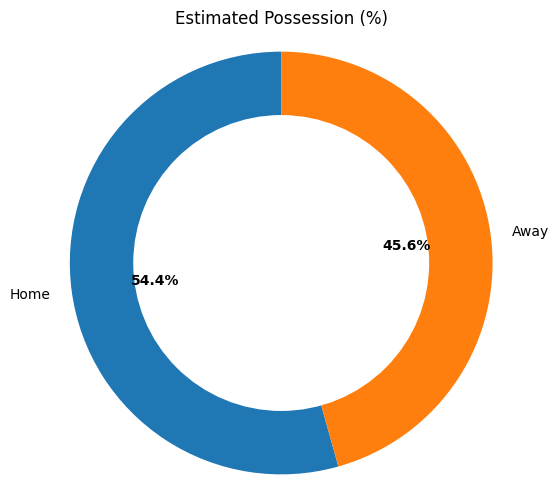

In [342]:

fig, ax = plt.subplots(figsize=(6, 6))

# Create the pie chart (donut base)
wedges, texts, autotexts = ax.pie(
    possession.round(2),
    labels=possession.index,           # Category labels
    autopct='%1.1f%%',            # Percentage format
    startangle=90,                # Start from top
    wedgeprops=dict(width=0.4),   # Width < 1 makes it a donut
    textprops=dict(color="black") # Label text color
)

# Customize label appearance
plt.setp(autotexts, size=10, weight="bold", color="black")
plt.setp(texts, size=10)

# Add a center circle for the donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Equal aspect ratio ensures the pie is drawn as a circle
ax.axis('equal')


plt.title('Estimated Possession (%)')



plt.show()

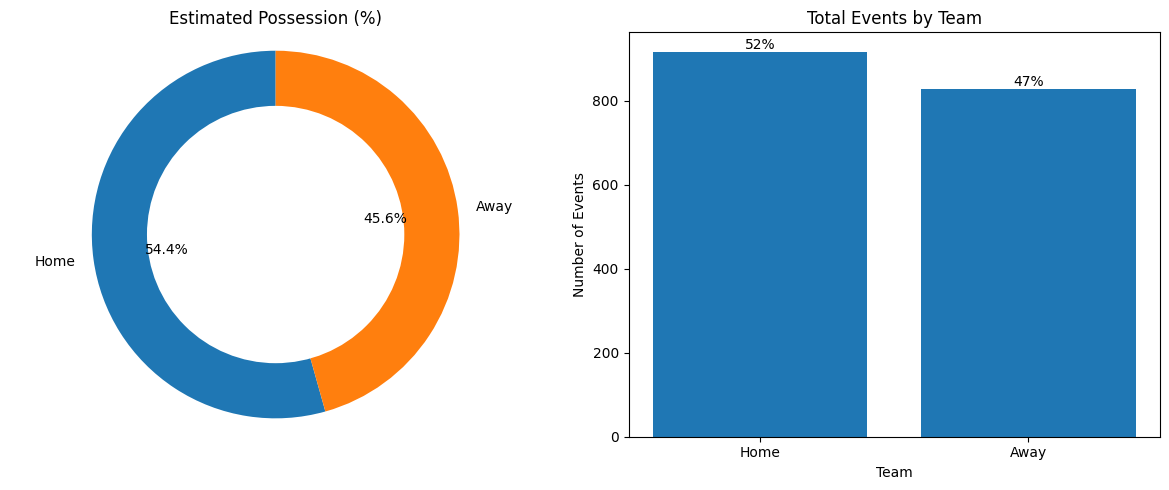

In [343]:
team_events = events['Team'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# --- Possession Donut ---
wedges, texts, autotexts = axes[0].pie(
    possession.round(2),
    labels=possession.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4)
)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
axes[0].add_artist(centre_circle)

axes[0].set_title('Estimated Possession (%)')
axes[0].axis('equal')


# --- Total Events ---
bars = axes[1].bar(team_events.index, team_events.values)

axes[1].set_title('Total Events by Team')
axes[1].set_ylabel('Number of Events')
axes[1].set_xlabel('Team')

# Add data labels above bars
for bar in bars:
    height = bar.get_height()
    pct=(height / team_events.sum() * 100)
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(pct)}%',
        ha='center',
        va='bottom'
    )


plt.tight_layout()
plt.show()

There is a correlation between possesion and total events per team

#### Pass Completion [%]

Check if type PASS has To NaN

In [344]:
events[(events['Type'] == 'PASS') & (events['To'].isna())]

,Team,Type,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y,Subtype_clean


All passes are completed so we will check with other type

In [345]:
events['Type'].value_counts()

Type
PASS              799
RECOVERY          278
BALL LOST         257
CHALLENGE         233
SET PIECE          77
BALL OUT           51
SHOT               24
FAULT RECEIVED     22
CARD                4
Name: count, dtype: int64

We see that all the other Types are those that have NaN in To column but we cannot be sure if the ball is lost through pass.

We will instead find average passes per possession

In [346]:
possession_end = ['BALL LOST', 'BALL OUT', 'SHOT', 'FOUL RECEIVED', 'SET PIECE']

passes_per_possession = []

current_passes = 0

for _, row in events.iterrows():

    if row['Type'] == 'PASS':
        current_passes += 1

    if row['Type'] in possession_end:
        passes_per_possession.append(current_passes)
        current_passes = 0

In [347]:
team_passes = {'Home': [], 'Away': []}

current_passes = 0
current_team = None

for _, row in events.iterrows():

    if row['Type'] == 'PASS':
        current_passes += 1
        current_team = row['Team']

    if row['Type'] in possession_end and current_team is not None:
        team_passes[current_team].append(current_passes)
        current_passes = 0
        current_team = None

In [348]:
avg_passes_team = {
    team: np.mean(vals) for team, vals in team_passes.items()
}

avg_passes_team

{'Home': np.float64(3.8035714285714284), 'Away': np.float64(3.73)}

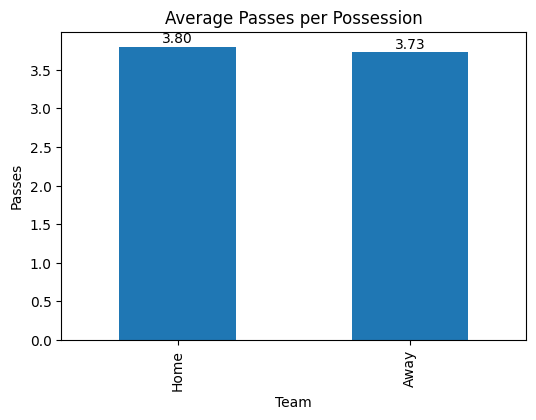

In [349]:
import pandas as pd
import matplotlib.pyplot as plt

pd.Series(avg_passes_team).plot(kind='bar', figsize=(6,4))

plt.title('Average Passes per Possession')
plt.ylabel('Passes')
plt.xlabel('Team')

for i, v in enumerate(avg_passes_team.values()):
    plt.text(i, v + 0.05, f"{v:.2f}", ha='center')

plt.show()

The two teams are pretty similar in build up and possession

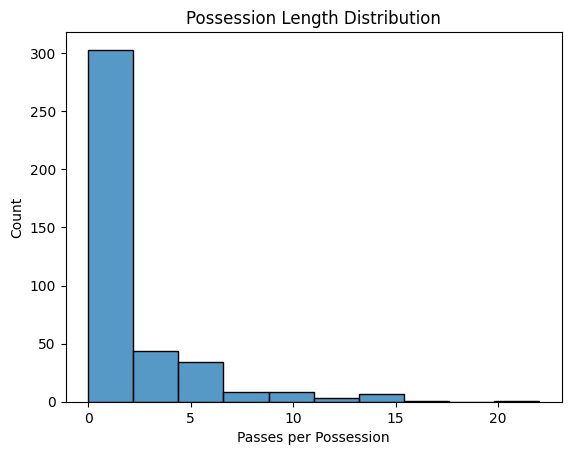

In [350]:
import seaborn as sns

sns.histplot(passes_per_possession, bins=10)

plt.title('Possession Length Distribution')
plt.xlabel('Passes per Possession')
plt.ylabel('Count')

plt.show()

#### Passing Network Graph (players + passes)

##### Counts passes per pair

In [351]:
pass_pairs = pass_events.groupby(['From','To', 'Team']).size().reset_index(name='count')
pass_pairs.sort_values('count', ascending=False).head(10)

,From,To,Team,count
86,Player19,Player21,Away,13
177,Player4,Player8,Home,13
204,Player7,Player2,Home,13
100,Player2,Player7,Home,12
117,Player21,Player19,Away,11
163,Player3,Player2,Home,11
186,Player5,Player7,Home,11
190,Player6,Player10,Home,10
115,Player21,Player17,Away,10
215,Player8,Player4,Home,10


In [352]:
import networkx as nx

G = nx.DiGraph()

for _, row in pass_pairs.iterrows():
    G.add_edge(row['From'], row['To'], weight=row['count'])

In [353]:
pos = nx.spring_layout(G, seed=42)

#### Passes heatmap per halves

First find kick offs

In [354]:
kickoffs = events[events['Subtype_clean'] == 'KICK OFF'][['Team','Start Time [s]']]

kickoffs['minute'] = kickoffs['Start Time [s]'] / 60

kickoffs

,Team,Start Time [s],minute
0,Away,0.04,0.000667
35,Away,147.00,2.450000
892,Home,2885.40,48.090000
1094,Home,3551.68,59.194667
1115,Away,3668.20,61.136667
1214,Away,4026.12,67.102000


#### Kick-off Events Interpretation

By examining the `KICK OFF` events and their timestamps we can identify key moments in the match, such as the start of the game, the start of the second half, and goals.

| Event | Time (seconds) | Time (minutes) | Interpretation |
|------|------|------|------|
| 1 | 0.04 | ~0 | Kick-off of the match |
| 2 | 147 | ~2.45 | Kick-off after a goal |
| 3 | 2885 | ~48 | Kick-off of the second half |
| 4 | 3551 | ~59 | Kick-off after a goal |
| 5 | 3668 | ~61 | Kick-off after a goal |
| 6 | 4026 | ~67 | Kick-off after a goal |

##### Interpretation

1. **0.04 seconds (~0 minutes)**  
   - This corresponds to the **start of the match**.

2. **147 seconds (~2.45 minutes)**  
   - A new kick-off occurs shortly after the match begins.  
   - This indicates that **a goal was scored early in the match**, followed by the restart from the center.

3. **2885 seconds (~48 minutes)**  
   - This kick-off corresponds to the **start of the second half**.

4. **3551 seconds (~59 minutes)**  
   - Kick-off after another **goal scored in the second half**.

5. **3668 seconds (~61 minutes)**  
   - Another **goal shortly after**, leading to a new kick-off.

6. **4026 seconds (~67 minutes)**  
   - Yet another **goal event**, followed by a restart.

##### Match Timeline Insight

Using the kick-off events we can determine the match structure:

- **First half:** `0 – 2885 seconds`
- **Second half:** `2885 seconds – end of match`

Kick-offs that occur **during play (not at the beginning of a half)** indicate that **a goal has been scored**, since the game always restarts from the center circle after a goal.

From the data we observe **multiple kick-offs during play**, suggesting several goals occurred throughout the match.

#### Create mirror coordinates as teams change direction

In [355]:
events_mirror = events.copy()

# halftime που βρήκαμε
halftime = 2885.4

mask_2h = events_mirror['Start Time [s]'] >= halftime

events_mirror.loc[mask_2h, 'Start X'] = 1 - events_mirror.loc[mask_2h, 'Start X']
events_mirror.loc[mask_2h, 'Start Y'] = 1 - events_mirror.loc[mask_2h, 'Start Y']

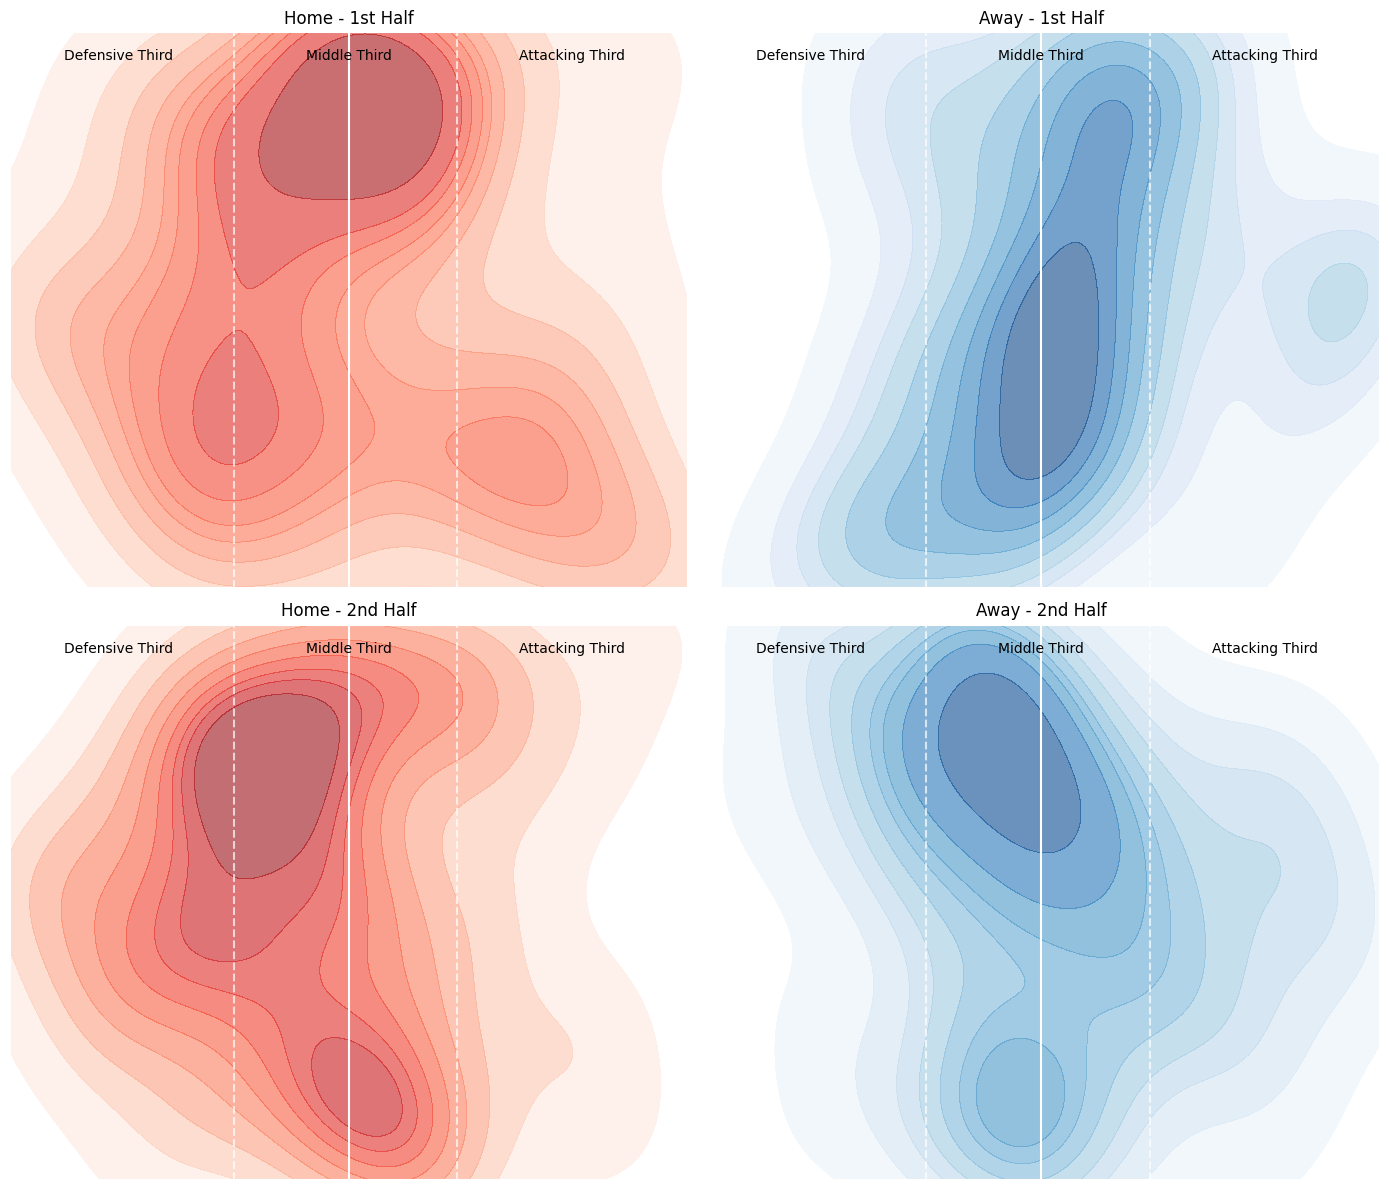

In [356]:
import matplotlib.pyplot as plt
import seaborn as sns

# halftime from kick-off detection
halftime = 2885.4

# mirror 2nd half
events_mirror = events.copy()

mask_2h = events_mirror['Start Time [s]'] >= halftime

events_mirror.loc[mask_2h, 'Start X'] = 1 - events_mirror.loc[mask_2h, 'Start X']
events_mirror.loc[mask_2h, 'Start Y'] = 1 - events_mirror.loc[mask_2h, 'Start Y']


# split halves
first_half = events_mirror[events_mirror['Start Time [s]'] < halftime]
second_half = events_mirror[events_mirror['Start Time [s]'] >= halftime]

# filter passes
passes_1h = first_half[first_half['Type'] == 'PASS']
passes_2h = second_half[second_half['Type'] == 'PASS']

home_1h = passes_1h[passes_1h['Team'] == 'Home']
away_1h = passes_1h[passes_1h['Team'] == 'Away']

home_2h = passes_2h[passes_2h['Team'] == 'Home']
away_2h = passes_2h[passes_2h['Team'] == 'Away']


# coordinates
x_home1 = home_1h['Start X'] * 100
y_home1 = home_1h['Start Y'] * 100

x_away1 = away_1h['Start X'] * 100
y_away1 = away_1h['Start Y'] * 100

x_home2 = home_2h['Start X'] * 100
y_home2 = home_2h['Start Y'] * 100

x_away2 = away_2h['Start X'] * 100
y_away2 = away_2h['Start Y'] * 100


fig, axes = plt.subplots(2,2, figsize=(14,12))

for ax in axes.flatten():

    ax.set_facecolor('#4CAF50')

    ax.plot([0,100],[0,0], color="white")
    ax.plot([0,0],[0,100], color="white")
    ax.plot([100,100],[0,100], color="white")
    ax.plot([0,100],[100,100], color="white")

    ax.plot([50,50],[0,100], color="white")

    ax.set_xlim(0,100)
    ax.set_ylim(0,100)
    ax.axvline(33, color='white', linestyle='--', alpha=0.7)
    ax.axvline(66, color='white', linestyle='--', alpha=0.7)

    # labels
    ax.text(16, 95, "Defensive Third", color='black', ha='center', fontsize=10)
    ax.text(50, 95, "Middle Third", color='black', ha='center', fontsize=10)
    ax.text(83, 95, "Attacking Third", color='black', ha='center', fontsize=10)

    ax.axis('off')


# 1st half
sns.kdeplot(x=x_home1, y=y_home1, fill=True, cmap="Reds", alpha=0.6, ax=axes[0,0])
axes[0,0].set_title("Home - 1st Half")

sns.kdeplot(x=x_away1, y=y_away1, fill=True, cmap="Blues", alpha=0.6, ax=axes[0,1])
axes[0,1].set_title("Away - 1st Half")


# 2nd half
sns.kdeplot(x=x_home2, y=y_home2, fill=True, cmap="Reds", alpha=0.6, ax=axes[1,0])
axes[1,0].set_title("Home - 2nd Half")

sns.kdeplot(x=x_away2, y=y_away2, fill=True, cmap="Blues", alpha=0.6, ax=axes[1,1])
axes[1,1].set_title("Away - 2nd Half")


plt.tight_layout()
plt.show()

From the heatmap it appears that home team slightly moves back its build up in the second half following their lead in score probably. They usually attack from the left wing. On the other hand the away team favorites central build up especially in he first half.

### Create passing network

In [357]:
def passing_network(events_df, team_name):

    # filter passes
    passes = events_df[
        (events_df['Type'] == 'PASS') &
        (events_df['Team'] == team_name)
    ].dropna(subset=['From','To'])

    # average player positions
    player_pos = (
        passes.groupby('From')[['Start X','Start Y']]
        .mean()
        * 100
    )

    # pass connections
    pass_pairs = (
        passes.groupby(['From','To'])
        .size()
        .reset_index(name='count')
    )

    return player_pos, pass_pairs

### Plot passing network function

In [358]:
def plot_network_pro(ax, player_pos, pass_pairs, title, color):

    # background
    ax.set_facecolor('#0b0f1a')

    # --- pitch outline ---
    ax.plot([0,100],[0,0], color="white", lw=2)
    ax.plot([0,0],[0,100], color="white", lw=2)
    ax.plot([100,100],[0,100], color="white", lw=2)
    ax.plot([0,100],[100,100], color="white", lw=2)

    # halfway line
    ax.plot([50,50],[0,100], color="white", lw=2, linestyle='--', alpha=0.6)

    # --- centre circle ---
    centre_circle = plt.Circle((50,50), 10, color='white', fill=False, lw=2)
    ax.add_patch(centre_circle)

    # --- penalty areas ---
    # left
    ax.plot([0,16],[21,21], color="white", lw=2)
    ax.plot([16,16],[21,79], color="white", lw=2)
    ax.plot([16,0],[79,79], color="white", lw=2)

    # right
    ax.plot([100,84],[21,21], color="white", lw=2)
    ax.plot([84,84],[21,79], color="white", lw=2)
    ax.plot([84,100],[79,79], color="white", lw=2)

    # --- goals ---
    # left goal
    ax.plot([-2,0],[44,44], color="white", lw=3)
    ax.plot([-2,0],[56,56], color="white", lw=3)
    ax.plot([-2,-2],[44,56], color="white", lw=3)

    # right goal
    ax.plot([100,102],[44,44], color="white", lw=3)
    ax.plot([100,102],[56,56], color="white", lw=3)
    ax.plot([102,102],[44,56], color="white", lw=3)

    ax.set_xlim(-5,105)
    ax.set_ylim(0,100)
    ax.axis('off')

    # --- filter edges ---
    pass_pairs = pass_pairs[pass_pairs['count'] >= 2]

    # --- edges ---
    for _, row in pass_pairs.iterrows():

        if row['From'] in player_pos.index and row['To'] in player_pos.index:

            x1, y1 = player_pos.loc[row['From']]
            x2, y2 = player_pos.loc[row['To']]

            ax.plot(
                [x1, x2],
                [y1, y2],
                linewidth=row['count'] * 1.2,
                color=color,
                alpha=0.5,
                zorder=1
            )

    # --- node sizes ---
    pass_counts = pass_pairs.groupby('From')['count'].sum()

    for player, pos in player_pos.iterrows():

        size = pass_counts.get(player, 1) * 120   # 👈 bigger nodes

        ax.scatter(
            pos['Start X'],
            pos['Start Y'],
            s=size,
            color=color,
            edgecolor='white',
            linewidth=2,
            zorder=3
        )

        # bigger, cleaner labels
        label = player.replace('Player','')

        ax.text(
            pos['Start X'],
            pos['Start Y'],
            label,
            ha='center',
            va='center',
            color='white',
            fontsize=12,   # 👈 bigger font
            weight='bold'
        )

    ax.set_title(title, color='white', fontsize=16)

### Plot passing network per team and half times

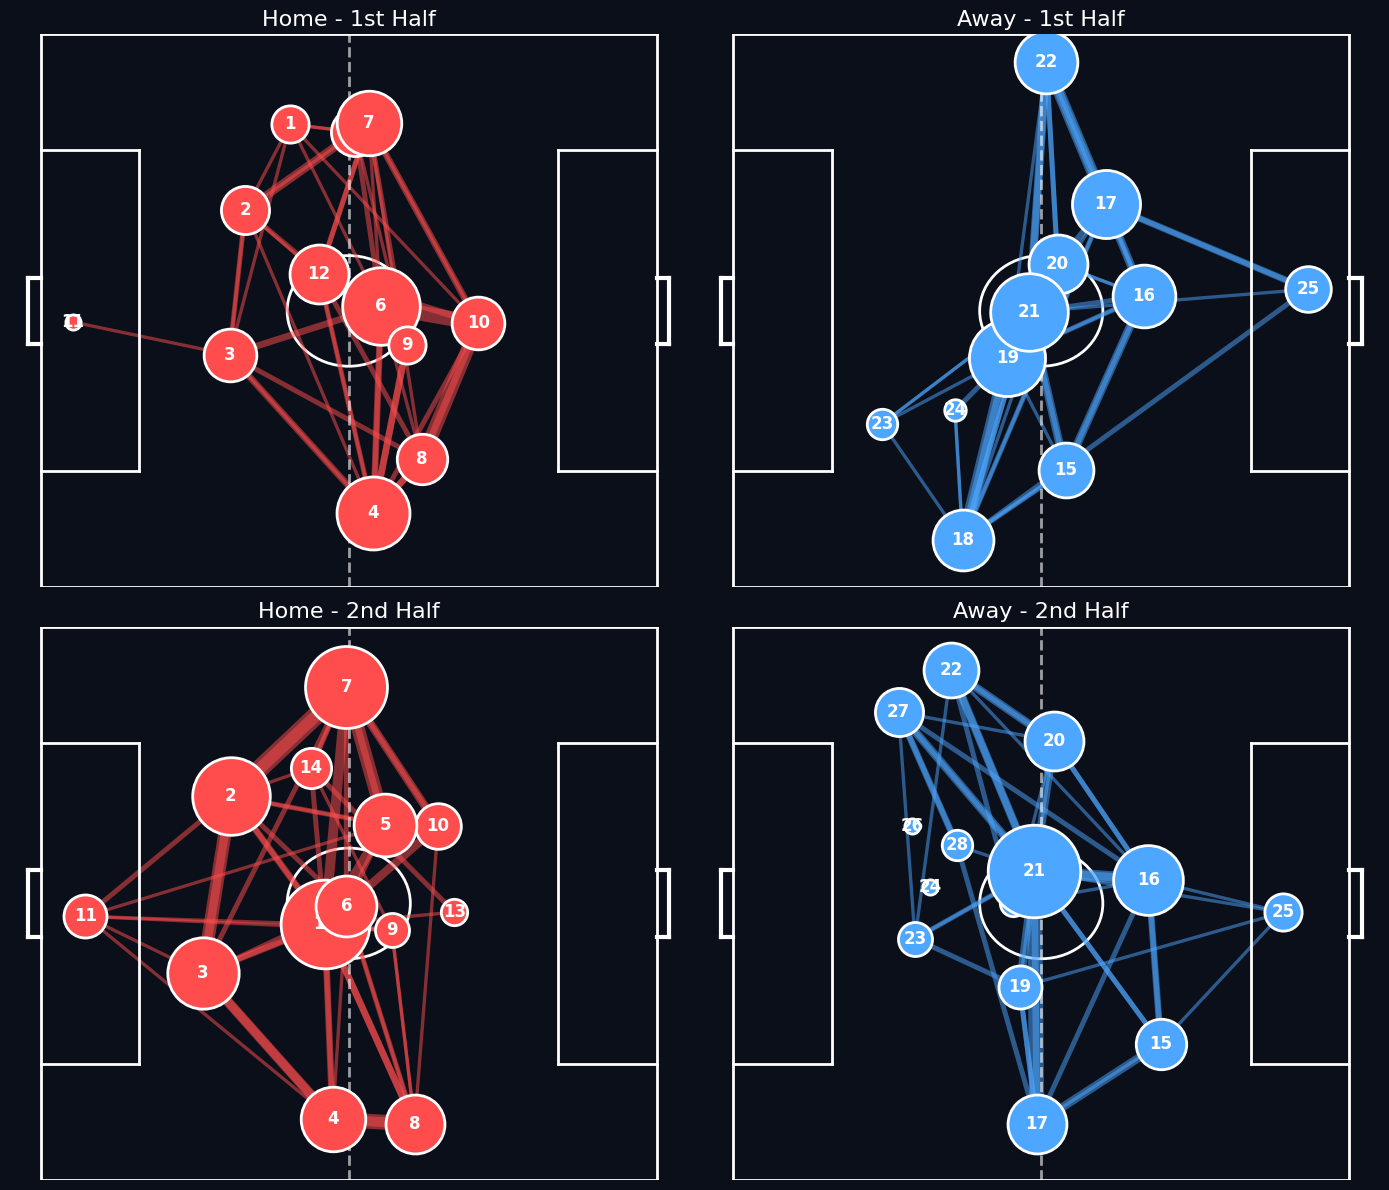

In [359]:
fig, axes = plt.subplots(2, 2, figsize=(14,12), facecolor='#0b0f1a')

# networks
hp1, pp1 = passing_network(first_half, 'Home')
ap1, ap_pairs1 = passing_network(first_half, 'Away')

hp2, pp2 = passing_network(second_half, 'Home')
ap2, ap_pairs2 = passing_network(second_half, 'Away')

# plot
plot_network_pro(axes[0,0], hp1, pp1, "Home - 1st Half", "#ff4d4d")
plot_network_pro(axes[0,1], ap1, ap_pairs1, "Away - 1st Half", "#4da6ff")

plot_network_pro(axes[1,0], hp2, pp2, "Home - 2nd Half", "#ff4d4d")
plot_network_pro(axes[1,1], ap2, ap_pairs2, "Away - 2nd Half", "#4da6ff")

plt.tight_layout()
plt.show()

#### Find the goalkeepers

In [360]:
events[events['Subtype_clean'] == 'GOAL KICK'][['From','Team']].value_counts()

From      Team
Player25  Away    10
Player11  Home     7
Name: count, dtype: int64

Player25 is away team gk and Player11 is home team gk

## Create Match Summary Statistics Table


### Goals

In [361]:
unique_events = events['Subtype_clean'].unique()
unique_events

array(['KICK OFF', 'NORMAL PASS', 'INTERCEPTION', 'HEAD-INTERCEPTION',
       'AERIAL-LOST', 'AERIAL-WON', 'HEAD', 'BALL OUT', 'CORNER KICK',
       'CROSS', 'HEAD-ON TARGET-GOAL', 'THROW IN', 'BALL LOST',
       'RECOVERY', 'GROUND-LOST', 'GROUND-WON', 'TACKLE-WON', 'THEFT',
       'TACKLE-LOST', 'OFF TARGET-OUT', 'GOAL KICK', 'CROSS-INTERCEPTION',
       'GOAL KICK-INTERCEPTION', 'DEEP BALL', 'ON TARGET-SAVED', 'SAVED',
       'HEAD-FORCED', 'AERIAL-FAULT-LOST', 'AERIAL-FAULT-WON',
       'FREE KICK', 'HEAD-CLEARANCE', 'CLEARANCE', 'GROUND-FAULT-WON',
       'FAULT RECEIVED', 'GROUND-FAULT-LOST', 'HEAD-OFF TARGET-OUT',
       'DRIBBLE-WON', 'OFFSIDE', 'TACKLE-FAULT-LOST', 'TACKLE-FAULT-WON',
       'GROUND', 'FORCED', 'YELLOW', 'THROUGH BALL-DEEP BALL',
       'HEAD-ON TARGET-SAVED', 'BLOCKED', 'TACKLE-ADVANTAGE-LOST',
       'TACKLE-ADVANTAGE-WON', 'GROUND-ADVANTAGE-LOST', 'END HALF',
       'HEAD-WOODWORK-OUT', 'WOODWORK-GOAL', 'ON TARGET-GOAL', 'WOODWORK',
       'REFEREE HIT', 'O

In [362]:
goals = events[(events['Subtype_clean'] == 'WOODWORK-GOAL')
                | (events['Subtype_clean'] == 'ON TARGET-GOAL')
                | (events['Subtype_clean'] == 'HEAD-ON TARGET-GOAL')].groupby('Team').size()
goals

Team
Home    4
dtype: int64

In [363]:
events[
    events['Subtype_clean'].str.contains('-GOAL', na=False)
]['Subtype_clean'].value_counts()

Subtype_clean
ON TARGET-GOAL         2
HEAD-ON TARGET-GOAL    1
WOODWORK-GOAL          1
Name: count, dtype: int64

#### Those are the goal events

In [364]:
events[
    events['Subtype_clean'].str.contains('-GOAL')
][['Team','Subtype_clean','Start Time [s]','End Time [s]','Start Frame','End Frame']]

,Team,Subtype_clean,Start Time [s],End Time [s],Start Frame,End Frame
34,Home,HEAD-ON TARGET-GOAL,91.56,92.36,2289,2309
1093,Home,WOODWORK-GOAL,3498.80,3499.40,87470,87485
1114,Home,ON TARGET-GOAL,3600.20,3601.04,90005,90026
1213,Home,ON TARGET-GOAL,3961.28,3961.84,99032,99046


#### Those are kick offs - we have missmatch

In [365]:
events[events['Subtype_clean']=='KICK OFF'][['Team','Start Time [s]','End Time [s]','Start Frame','End Frame']]

,Team,Start Time [s],End Time [s],Start Frame,End Frame
0,Away,0.04,0.00,1,0
35,Away,147.00,147.00,3675,3675
892,Home,2885.40,2885.40,72135,72135
1094,Home,3551.68,3551.68,88792,88792
1115,Away,3668.20,3668.20,91705,91705
1214,Away,4026.12,4026.12,100653,100653


#### We will take into account only the -GOAL events and not the kick offs

##### Next we should find fouls

In [366]:
faults = (
    events[events['Subtype_clean'].str.contains('FAULT', na=False)]
    .groupby(['Team','Subtype_clean'])
    .size()
    .unstack(fill_value=0)
)

faults

Subtype_clean,AERIAL-FAULT-LOST,AERIAL-FAULT-WON,FAULT RECEIVED,GROUND-FAULT-LOST,GROUND-FAULT-WON,TACKLE-FAULT-LOST,TACKLE-FAULT-WON
Team,,,,,,,
Away,2,2,7,6,3,11,7
Home,2,2,15,2,7,6,9


##### Check if fouls committed from one team= Fouls received from another

In [367]:
events[events['Subtype_clean'].str.contains('FAULT')].groupby(['Team','Subtype_clean']).size()

Team  Subtype_clean    
Away  AERIAL-FAULT-LOST     2
      AERIAL-FAULT-WON      2
      FAULT RECEIVED        7
      GROUND-FAULT-LOST     6
      GROUND-FAULT-WON      3
      TACKLE-FAULT-LOST    11
      TACKLE-FAULT-WON      7
Home  AERIAL-FAULT-LOST     2
      AERIAL-FAULT-WON      2
      FAULT RECEIVED       15
      GROUND-FAULT-LOST     2
      GROUND-FAULT-WON      7
      TACKLE-FAULT-LOST     6
      TACKLE-FAULT-WON      9
dtype: int64

##### We see that fault-lost of the away team=faults won for the home team

The fault received are probably extra fouls not in competitive ball

In [368]:
import pandas as pd

summary = {}

# Possession
summary['Possession %'] = possession


# Goals
summary['Goals'] = (
    events[events['Subtype_clean'].str.contains('-GOAL', na=False)]
    .groupby('Team')
    .size()
)


# Shots
summary['Shots'] = (
    events[events['Type'] == 'SHOT']
    .groupby('Team')
    .size()
)


# Shots on target (goal + saved)
summary['Shots on Target'] = (
    events[
        events['Subtype_clean'].str.contains('ON TARGET|-GOAL', na=False)
    ]
    .groupby('Team')
    .size()
)


# Saves
summary['Saves'] = (
    events[
        events['Subtype_clean'].str.contains('SAVED', na=False)
    ]
    .groupby('Team')
    .size()
)


# Woodwork (exclude goals)
summary['Woodwork'] = (
    events[
        events['Subtype_clean'].str.contains('WOODWORK', na=False) &
        ~events['Subtype_clean'].str.contains('GOAL', na=False)
    ]
    .groupby('Team')
    .size()
)


# Corners
summary['Corners'] = (
    events[events['Subtype_clean'] == 'CORNER KICK']
    .groupby('Team')
    .size()
)


# Offsides
summary['Offsides'] = (
    events[events['Subtype_clean'] == 'OFFSIDE']
    .groupby('Team')
    .size()
)


# Fouls
# fouls won / received
fouls_suffered = (
    events[
        events['Subtype_clean'].str.contains('FAULT RECEIVED|FAULT-WON', na=False)
    ]
    .groupby('Team')
    .size()
)

# fouls committed = opponent fouls suffered
fouls_committed = fouls_suffered.copy()

fouls_committed['Home'] = fouls_suffered.get('Away', 0)
fouls_committed['Away'] = fouls_suffered.get('Home', 0)

summary['Fouls'] = fouls_committed


# Yellow cards
summary['Yellow Cards'] = (
    events[events['Subtype_clean'] == 'YELLOW']
    .groupby('Team')
    .size()
)


# Build table
match_summary = (
    pd.DataFrame(summary)
    .reindex(['Home','Away'])
    .fillna(0)
)


# Formatting
match_summary['Possession %'] = match_summary['Possession %'].round(2)

for col in match_summary.columns:
    if col != 'Possession %':
        match_summary[col] = match_summary[col].astype(int)


# Head-to-head layout
match_summary_h2h = match_summary.T

match_summary_h2h

Team,Home,Away
Possession %,54.36,45.64
Goals,4.00,0.00
Shots,18.00,6.00
Shots on Target,8.00,3.00
Saves,7.00,7.00
Woodwork,1.00,1.00
Corners,8.00,3.00
Offsides,0.00,1.00
Fouls,19.00,33.00
Yellow Cards,2.00,2.00


#### Sanity check for saves

In [369]:
on_target_saved = events[events['Subtype_clean']=='ON TARGET-SAVED'].groupby(['Subtype_clean','Team']).size().reset_index(name='Count')
print(on_target_saved.sort_values('Count', ascending=False))

head_on_target = events[events['Subtype_clean']=='HEAD-ON TARGET-SAVED'].groupby(['Subtype_clean','Team']).size().reset_index(name='Count')
print(head_on_target.sort_values('Count', ascending=False))

saved = events[events['Subtype_clean']=='SAVED'].groupby(['Subtype_clean','Team']).size().reset_index(name='Count')
print(saved.sort_values('Count', ascending=False))

total_saved = (
    events[
        events['Subtype_clean'].isin([
            'ON TARGET-SAVED',
            'HEAD-ON TARGET-SAVED',
            'SAVED'
        ])
    ]
    .groupby('Team')
    .size()
)

total_saved

     Subtype_clean  Team  Count
0  ON TARGET-SAVED  Away      3
1  ON TARGET-SAVED  Home      2
          Subtype_clean  Team  Count
0  HEAD-ON TARGET-SAVED  Home      2
  Subtype_clean  Team  Count
0         SAVED  Away      4
1         SAVED  Home      3


Team
Away    7
Home    7
dtype: int64

#### Sanity check for fouls

In [370]:
total_fouls = (
    events[
        events['Subtype_clean'].isin([
            'AERIAL-FAULT-WON',
            'FAULT RECEIVED',
            
            'GROUND-FAULT-WON',
            
            'TACKLE-FAULT-WON'
        ])
    ]
    .groupby('Team')
    .size()
)

total_fouls

Team
Away    19
Home    33
dtype: int64

## Shot Map

### Extract Shots

In [371]:
shots = events[events['Type'] == 'SHOT']
shots 

,Team,Type,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y,Subtype_clean
34,Home,SHOT,1,2289,91.56,2309,92.36,Player9,NaN,0.92,0.47,1.01,0.55,HEAD-ON TARGET-GOAL
79,Home,SHOT,1,5923,236.92,5953,238.12,Player10,NaN,0.84,0.27,1.04,0.60,OFF TARGET-OUT
110,Away,SHOT,1,7753,310.12,7789,311.56,Player21,NaN,0.20,0.30,-0.04,0.65,OFF TARGET-OUT
135,Home,SHOT,1,9628,385.12,9632,385.28,Player8,NaN,0.96,0.37,0.98,0.46,ON TARGET-SAVED
239,Home,SHOT,1,18270,730.80,18301,732.04,Player8,NaN,0.94,0.55,1.03,0.61,HEAD-OFF TARGET-OUT
254,Away,SHOT,1,19470,778.80,19483,779.32,Player24,NaN,0.13,0.37,0.02,0.48,ON TARGET-SAVED
362,Home,SHOT,1,26608,1064.32,26636,1065.44,Player8,NaN,0.95,0.53,1.03,0.47,HEAD-OFF TARGET-OUT
425,Home,SHOT,1,31190,1247.60,31235,1249.40,Player7,NaN,0.75,0.37,1.05,0.59,OFF TARGET-OUT
662,Home,SHOT,1,53695,2147.80,53707,2148.28,Player8,NaN,0.94,0.52,1.00,0.54,HEAD-ON TARGET-SAVED
667,Home,SHOT,1,53775,2151.00,53775,2151.00,Player5,NaN,0.86,0.72,0.89,0.73,BLOCKED


### Group by team

In [372]:
shots.groupby('Team').size()

Team
Away     6
Home    18
dtype: int64

### Find shot position

In [373]:
shots['x'] = shots['Start X'] * 100
shots['y'] = shots['Start Y'] * 100

C:\Users\30697\AppData\Local\Temp\ipykernel_10760\4244317909.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shots['x'] = shots['Start X'] * 100
C:\Users\30697\AppData\Local\Temp\ipykernel_10760\4244317909.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shots['y'] = shots['Start Y'] * 100


### Highlight goals

In [374]:
shots['Goal'] = shots['Subtype_clean'].str.contains('GOAL', na=False)

C:\Users\30697\AppData\Local\Temp\ipykernel_10760\3708263430.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shots['Goal'] = shots['Subtype_clean'].str.contains('GOAL', na=False)


### Build shot map
red:Goal

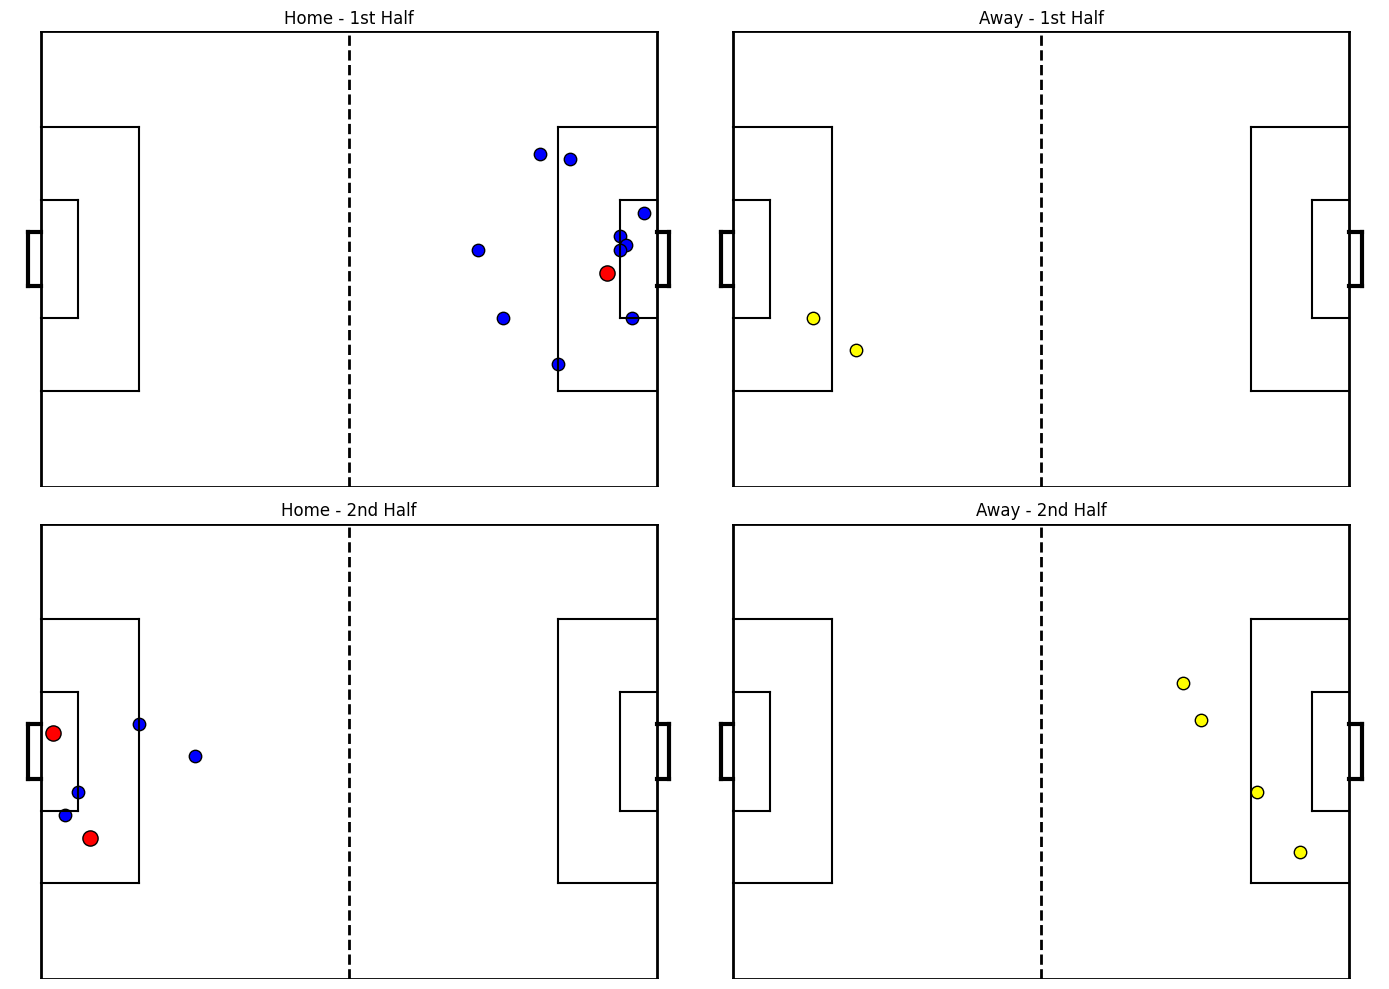

In [375]:
import matplotlib.pyplot as plt

# halftime
halftime = 2885.4

# filter shots
shots = events[events['Type'] == 'SHOT'].copy()

# coordinates
shots['x'] = shots['Start X'] * 100
shots['y'] = shots['Start Y'] * 100

# goal flag
shots['Goal'] = shots['Subtype_clean'].str.contains('GOAL', na=False)

# split halves
shots_1h = shots[shots['Start Time [s]'] < halftime]
shots_2h = shots[shots['Start Time [s]'] >= halftime]

# split teams
home_1h = shots_1h[shots_1h['Team']=='Home']
away_1h = shots_1h[shots_1h['Team']=='Away']

home_2h = shots_2h[shots_2h['Team']=='Home']
away_2h = shots_2h[shots_2h['Team']=='Away']


fig, axes = plt.subplots(2,2, figsize=(14,10))

for ax in axes.flatten():

    ax.set_facecolor('#4CAF50')

    # pitch outline
    ax.plot([0,100],[0,0], color='black', linewidth=2)
    ax.plot([0,0],[0,100], color='black', linewidth=2)
    ax.plot([100,100],[0,100], color='black', linewidth=2)
    ax.plot([0,100],[100,100], color='black', linewidth=2)

    # halfway line
    ax.plot([50,50],[0,100], color='black', linewidth=2, linestyle='--')

    # penalty areas
    ax.plot([0,16],[21,21], color='black')
    ax.plot([16,16],[21,79], color='black')
    ax.plot([16,0],[79,79], color='black')

    ax.plot([100,84],[21,21], color='black')
    ax.plot([84,84],[21,79], color='black')
    ax.plot([84,100],[79,79], color='black')

    # 6-yard boxes
    ax.plot([0,6],[37,37], color='black')
    ax.plot([6,6],[37,63], color='black')
    ax.plot([6,0],[63,63], color='black')

    ax.plot([100,94],[37,37], color='black')
    ax.plot([94,94],[37,63], color='black')
    ax.plot([94,100],[63,63], color='black')

    # goals
    ax.plot([-2,0],[44,44], color='black', linewidth=3)
    ax.plot([-2,0],[56,56], color='black', linewidth=3)
    ax.plot([-2,-2],[44,56], color='black', linewidth=3)

    ax.plot([100,102],[44,44], color='black', linewidth=3)
    ax.plot([100,102],[56,56], color='black', linewidth=3)
    ax.plot([102,102],[44,56], color='black', linewidth=3)

    ax.set_xlim(-5,105)
    ax.set_ylim(0,100)

    ax.axis('off')


# Home 1H
axes[0,0].scatter(
    home_1h[~home_1h['Goal']]['x'],
    home_1h[~home_1h['Goal']]['y'],
    color='blue', edgecolor='black', s=80
)

axes[0,0].scatter(
    home_1h[home_1h['Goal']]['x'],
    home_1h[home_1h['Goal']]['y'],
    color='red', edgecolor='black', s=120
)

axes[0,0].set_title("Home - 1st Half")


# Away 1H
axes[0,1].scatter(
    away_1h[~away_1h['Goal']]['x'],
    away_1h[~away_1h['Goal']]['y'],
    color='yellow', edgecolor='black', s=80
)

axes[0,1].scatter(
    away_1h[away_1h['Goal']]['x'],
    away_1h[away_1h['Goal']]['y'],
    color='green', edgecolor='black', s=120
)

axes[0,1].set_title("Away - 1st Half")


# Home 2H
axes[1,0].scatter(
    home_2h[~home_2h['Goal']]['x'],
    home_2h[~home_2h['Goal']]['y'],
    color='blue', edgecolor='black', s=80
)

axes[1,0].scatter(
    home_2h[home_2h['Goal']]['x'],
    home_2h[home_2h['Goal']]['y'],
    color='red', edgecolor='black', s=120
)

axes[1,0].set_title("Home - 2nd Half")


# Away 2H
axes[1,1].scatter(
    away_2h[~away_2h['Goal']]['x'],
    away_2h[~away_2h['Goal']]['y'],
    color='yellow', edgecolor='black', s=80
)

axes[1,1].scatter(
    away_2h[away_2h['Goal']]['x'],
    away_2h[away_2h['Goal']]['y'],
    color='green', edgecolor='black', s=120
)

axes[1,1].set_title("Away - 2nd Half")


plt.tight_layout()
plt.show()

### From the map above we return to the inconsistency of goals and kick offs

#### Check goal events per time

In [376]:
events[
    events['Subtype_clean'].str.contains('-GOAL', na=False)
][['Team','Subtype_clean','Start Time [s]']].sort_values('Start Time [s]')

,Team,Subtype_clean,Start Time [s]
34,Home,HEAD-ON TARGET-GOAL,91.56
1093,Home,WOODWORK-GOAL,3498.80
1114,Home,ON TARGET-GOAL,3600.20
1213,Home,ON TARGET-GOAL,3961.28


#### Use kick offs for verification

In [377]:
kickoffs = events[events['Subtype_clean']=='KICK OFF']

score = kickoffs['Team'].value_counts() - 1
score

Team
Away    3
Home    1
Name: count, dtype: int64

#### Filter goals that trigger kick offs

In [401]:
goals = events[
    events['Subtype_clean'].str.contains('-GOAL', na=False)
].sort_values('Start Time [s]').copy()

kickoffs = events[
    events['Subtype_clean'] == 'KICK OFF'
].sort_values('Start Time [s]').copy()
goals

,Team,Type,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y,Subtype_clean
34,Home,SHOT,1,2289,91.56,2309,92.36,Player9,NaN,0.92,0.47,1.01,0.55,HEAD-ON TARGET-GOAL
1093,Home,BALL OUT,2,87470,3498.80,87485,3499.40,Player5,NaN,0.97,0.48,1.01,0.54,WOODWORK-GOAL
1114,Home,SHOT,2,90005,3600.20,90026,3601.04,Player10,NaN,0.08,0.31,0.00,0.54,ON TARGET-GOAL
1213,Home,SHOT,2,99032,3961.28,99046,3961.84,Player9,NaN,0.02,0.54,-0.01,0.51,ON TARGET-GOAL


#### match goal → next kickoff

In [402]:
valid_goals = []

for _, goal in goals.iterrows():

    t = goal['Start Time [s]']

    next_kick = kickoffs[kickoffs['Start Time [s]'] > t]

    if next_kick.empty:
        continue

    next_team = next_kick.iloc[0]['Team']

    # kickoff γίνεται από την ομάδα που ΔΕΝ σκόραρε
    if next_team != goal['Team']:
        valid_goals.append(goal)

In [403]:
valid_goals = pd.DataFrame(valid_goals)

valid_goals[['Team','Subtype_clean','Start Time [s]']]

,Team,Subtype_clean,Start Time [s]
34,Home,HEAD-ON TARGET-GOAL,91.56
1114,Home,ON TARGET-GOAL,3600.20
1213,Home,ON TARGET-GOAL,3961.28


In [404]:
valid_goals[['Start X','End X']]

,Start X,End X
34,0.92,1.01
1114,0.08,0.00
1213,0.02,-0.01


#### Fix the mismatch by labeling it own goal. It was probably own goal from deflection

In [405]:
final_goals = []

for _, goal in goals.iterrows():

    t = goal['Start Time [s]']
    scoring_team = goal['Team']

    next_kick = kickoffs[kickoffs['Start Time [s]'] > t]

    if next_kick.empty:
        continue

    kickoff_team = next_kick.iloc[0]['Team']

    if kickoff_team != scoring_team:
        goal_type = 'Normal Goal'
        final_team = scoring_team
    else:
        goal_type = 'Own Goal'
        final_team = 'Away' if scoring_team == 'Home' else 'Home'

    final_goals.append({
        'Time': t,
        'Original Team': scoring_team,
        'Final Team': final_team,
        'Type': goal_type,
        'Subtype': goal['Subtype_clean']
    })

In [407]:
final_goals = pd.DataFrame(final_goals)
final_goals

,Time,Original Team,Final Team,Type,Subtype
0,91.56,Home,Home,Normal Goal,HEAD-ON TARGET-GOAL
1,3498.80,Home,Away,Own Goal,WOODWORK-GOAL
2,3600.20,Home,Home,Normal Goal,ON TARGET-GOAL
3,3961.28,Home,Home,Normal Goal,ON TARGET-GOAL


### Tracking Away

In [379]:
tracking_away.shape

(145008, 33)

In [380]:
tracking_away.columns

Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Away', 'Unnamed: 4',
       'Away.1', 'Unnamed: 6', 'Away.2', 'Unnamed: 8', 'Away.3', 'Unnamed: 10',
       'Away.4', 'Unnamed: 12', 'Away.5', 'Unnamed: 14', 'Away.6',
       'Unnamed: 16', 'Away.7', 'Unnamed: 18', 'Away.8', 'Unnamed: 20',
       'Away.9', 'Unnamed: 22', 'Away.10', 'Unnamed: 24', 'Away.11',
       'Unnamed: 26', 'Away.12', 'Unnamed: 28', 'Away.13', 'Unnamed: 30',
       'Away.14', 'Unnamed: 32'],
      dtype='object')

In [381]:
tracking_away.head(10)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Away,Unnamed: 4,Away.1,Unnamed: 6,Away.2,Unnamed: 8,Away.3,...,Away.10,Unnamed: 24,Away.11,Unnamed: 26,Away.12,Unnamed: 28,Away.13,Unnamed: 30,Away.14,Unnamed: 32
0,NaN,NaN,NaN,25,NaN,15,NaN,16,NaN,17,...,24,NaN,26,NaN,27,NaN,28,NaN,NaN,NaN
1,Period,Frame,Time [s],Player25,NaN,Player15,NaN,Player16,NaN,Player17,...,Player24,NaN,Player26,NaN,Player27,NaN,Player28,NaN,Ball,NaN
2,1,1,0.04,0.90509,0.47462,0.58393,0.20794,0.67658,0.46710,0.6731,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.45472,0.38709
3,1,2,0.08,0.90494,0.47462,0.58393,0.20794,0.67658,0.46710,0.6731,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.49645,0.40656
4,1,3,0.12,0.90434,0.47463,0.58393,0.20794,0.67658,0.46710,0.6731,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.53716,0.42556
5,1,4,0.16,0.90377,0.47463,0.58351,0.20868,0.6764,0.46762,0.67279,...,0.37756,0.27473,NaN,NaN,NaN,NaN,NaN,NaN,0.55346,0.42231
6,1,5,0.2,0.90324,0.47464,0.58291,0.21039,0.67599,0.46769,0.67253,...,0.37663,0.27543,NaN,NaN,NaN,NaN,NaN,NaN,0.55512,0.40570
7,1,6,0.24,0.90275,0.47464,0.58214,0.21123,0.67537,0.46727,0.67194,...,0.37557,0.27673,NaN,NaN,NaN,NaN,NaN,NaN,0.55677,0.38909
8,1,7,0.28,0.90227,0.47465,0.58142,0.21166,0.67471,0.46658,0.67133,...,0.37439,0.27751,NaN,NaN,NaN,NaN,NaN,NaN,0.55842,0.37248
9,1,8,0.32,0.90213,0.47374,0.58067,0.21182,0.67406,0.46550,0.67063,...,0.3732,0.27848,NaN,NaN,NaN,NaN,NaN,NaN,0.56004,0.35629


### Tracking Home

In [382]:
tracking_home.shape

(145008, 33)

In [383]:
tracking_home.columns

Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Home', 'Unnamed: 4',
       'Home.1', 'Unnamed: 6', 'Home.2', 'Unnamed: 8', 'Home.3', 'Unnamed: 10',
       'Home.4', 'Unnamed: 12', 'Home.5', 'Unnamed: 14', 'Home.6',
       'Unnamed: 16', 'Home.7', 'Unnamed: 18', 'Home.8', 'Unnamed: 20',
       'Home.9', 'Unnamed: 22', 'Home.10', 'Unnamed: 24', 'Home.11',
       'Unnamed: 26', 'Home.12', 'Unnamed: 28', 'Home.13', 'Unnamed: 30',
       'Unnamed: 31', 'Unnamed: 32'],
      dtype='object')

In [384]:
tracking_home.head(10)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Home,Unnamed: 4,Home.1,Unnamed: 6,Home.2,Unnamed: 8,Home.3,...,Home.10,Unnamed: 24,Home.11,Unnamed: 26,Home.12,Unnamed: 28,Home.13,Unnamed: 30,Unnamed: 31,Unnamed: 32
0,NaN,NaN,NaN,11,NaN,1,NaN,2,NaN,3,...,10,NaN,12,NaN,13,NaN,14,NaN,NaN,NaN
1,Period,Frame,Time [s],Player11,NaN,Player1,NaN,Player2,NaN,Player3,...,Player10,NaN,Player12,NaN,Player13,NaN,Player14,NaN,Ball,NaN
2,1,1,0.04,0.00082,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.45472,0.38709
3,1,2,0.08,0.00096,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.49645,0.40656
4,1,3,0.12,0.00114,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.53716,0.42556
5,1,4,0.16,0.00121,0.48238,0.32622,0.65317,0.33687,0.48988,0.30944,...,0.55236,0.43313,NaN,NaN,NaN,NaN,NaN,NaN,0.55346,0.42231
6,1,5,0.2,0.00129,0.48238,0.32597,0.65269,0.33664,0.49018,0.30948,...,0.55202,0.43311,NaN,NaN,NaN,NaN,NaN,NaN,0.55512,0.40570
7,1,6,0.24,0.0014,0.48238,0.32581,0.65159,0.33637,0.48966,0.30978,...,0.55256,0.42793,NaN,NaN,NaN,NaN,NaN,NaN,0.55677,0.38909
8,1,7,0.28,0.0014,0.48238,0.3257,0.65037,0.33624,0.48919,0.31015,...,0.55307,0.42546,NaN,NaN,NaN,NaN,NaN,NaN,0.55842,0.37248
9,1,8,0.32,0.0014,0.48238,0.32564,0.64916,0.33608,0.48869,0.3105,...,0.55333,0.42315,NaN,NaN,NaN,NaN,NaN,NaN,0.56004,0.35629


#### Tracking Data Header Structure

The tracking CSV files contain two rows that actually define the column metadata rather than real observations.  
These rows need to be interpreted correctly before analyzing the data.

**Row 0 — Jersey Numbers**

The first row contains the jersey numbers associated with each tracked player.  
These numbers identify the player within the team.

**Row 1 — Player / Variable Names**

The second row contains the variable labels (e.g., `Player1`, `Player2`, etc.) or general column descriptors such as `Period`, `Frame`, and `Time [s]`.

**Rows 2+ — Actual Tracking Data**

From the third row onward, the dataset contains the real tracking observations recorded frame-by-frame during the match.  
Each row corresponds to a single frame and includes positional coordinates for players and the ball over time.

**Summary**

| Row | Content |
|----|----|
| Row 0 | Jersey numbers |
| Row 1 | Player / variable names |
| Row 2+ | Actual tracking data (frame-by-frame positions) |

Because of this structure, the first two rows should be combined to construct meaningful column names, and then removed before performing analysis.

#### Clean headers for both home and away teams

In [385]:
#—————— Home ————————#
jersey = tracking_home.iloc[0]
names = tracking_home.iloc[1]

# new column names
tracking_home.columns = [
    f"{n}_{j}" if pd.notna(n) and pd.notna(j) else n
    for n, j in zip(names, jersey)
]

# drop first two rows
tracking_home = tracking_home.iloc[2:].reset_index(drop=True)

#—————— Away ————————#
jersey = tracking_away.iloc[0]
names = tracking_away.iloc[1]

tracking_away.columns = [
    f"{n}_{j}" if pd.notna(n) and pd.notna(j) else n
    for n, j in zip(names, jersey)
]

tracking_away = tracking_away.iloc[2:].reset_index(drop=True)

#### Convert to x and y coordinates for each player

In [386]:
def rename_xy_columns(df):

    cols = df.columns.tolist()
    new_cols = []

    i = 0

    while i < len(cols):

        col = cols[i]
        #players
        if isinstance(col,str) and "Player" in col:

            player = col.split("_")[0]

            new_cols.append(f"{player}_x")
            new_cols.append(f"{player}_y")

            i += 2

        # ball
        elif col == "Ball":
            new_cols.append("ball_x")
            new_cols.append("ball_y")

            i += 2

        else:
            new_cols.append(col)
            i += 1

    df.columns = new_cols
    return df


tracking_home = rename_xy_columns(tracking_home)
tracking_away = rename_xy_columns(tracking_away)

In [387]:
print('Home team tracking data:')
print(tracking_home.head())

print('Away team tracking data:')
print(tracking_away.head())

Home team tracking data:
  Period Frame Time [s] Player11_x  Player11_y Player1_x  Player1_y Player2_x  \
0      1     1     0.04    0.00082     0.48238   0.32648    0.65322   0.33701   
1      1     2     0.08    0.00096     0.48238   0.32648    0.65322   0.33701   
2      1     3     0.12    0.00114     0.48238   0.32648    0.65322   0.33701   
3      1     4     0.16    0.00121     0.48238   0.32622    0.65317   0.33687   
4      1     5      0.2    0.00129     0.48238   0.32597    0.65269   0.33664   

   Player2_y Player3_x  ...  Player10_x Player10_y  Player12_x Player12_y  \
0    0.48863   0.30927  ...     0.55243    0.43269         NaN        NaN   
1    0.48863   0.30927  ...     0.55243    0.43269         NaN        NaN   
2    0.48863   0.30927  ...     0.55243    0.43269         NaN        NaN   
3    0.48988   0.30944  ...     0.55236    0.43313         NaN        NaN   
4    0.49018   0.30948  ...     0.55202    0.43311         NaN        NaN   

   Player13_x Player13_y 

#### Confirm that ball_x and ball_y are aligned for both tracking data

In [388]:
(tracking_home['ball_x'] == tracking_away['ball_x']).all(), \
(tracking_home['ball_y'] == tracking_away['ball_y']).all()

(np.False_, np.False_)

#### Take into consideration the floating precision

In [389]:
import numpy as np
# First convert to numeric, coercing errors to NaN
tracking_home['ball_x'] = pd.to_numeric(tracking_home['ball_x'], errors='coerce')
tracking_home['ball_y'] = pd.to_numeric(tracking_home['ball_y'], errors='coerce')

tracking_away['ball_x'] = pd.to_numeric(tracking_away['ball_x'], errors='coerce')
tracking_away['ball_y'] = pd.to_numeric(tracking_away['ball_y'], errors='coerce')

np.allclose(tracking_home['ball_x'], tracking_away['ball_x']), \
np.allclose(tracking_home['ball_y'], tracking_away['ball_y'])

(False, False)

#### Check max diff

In [390]:
diff_x = np.abs(tracking_home['ball_x'] - tracking_away['ball_x'])
diff_y = np.abs(tracking_home['ball_y'] - tracking_away['ball_y'])

diff_x.max(), diff_y.max()

(np.float64(0.0), np.float64(0.0))

#### Ball trajectory is the same
We might have NaN values

In [391]:
tracking_home[['ball_x','ball_y']].isna().sum()
tracking_away[['ball_x','ball_y']].isna().sum()

ball_x    56755
ball_y    56755
dtype: int64

#### We have missing values and we should handle them

# Passing Network Using Both Event and Tracking Data

### Passes

In [392]:
pass_events

,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y
1,Away,PASS,NaN,1,1,0.04,3,0.12,Player19,Player21,0.45,0.39,0.55,0.43
2,Away,PASS,NaN,1,3,0.12,17,0.68,Player21,Player15,0.55,0.43,0.58,0.21
3,Away,PASS,NaN,1,45,1.80,61,2.44,Player15,Player19,0.55,0.19,0.45,0.31
4,Away,PASS,NaN,1,77,3.08,96,3.84,Player19,Player21,0.45,0.32,0.49,0.47
5,Away,PASS,NaN,1,191,7.64,217,8.68,Player21,Player22,0.40,0.73,0.32,0.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1731,Away,PASS,NaN,2,142715,5708.60,142755,5710.20,Player20,Player27,0.41,0.33,0.60,0.04
1736,Away,PASS,NaN,2,143130,5725.20,143137,5725.48,Player16,Player18,0.50,0.37,0.61,0.53
1739,Home,PASS,NaN,2,143262,5730.48,143297,5731.88,Player14,Player12,0.75,0.22,0.71,0.28
1740,Home,PASS,NaN,2,143361,5734.44,143483,5739.32,Player12,Player13,0.60,0.33,0.19,0.95


### Use frame

In [393]:
pass_events['frame'] = pass_events['Start Frame']
pass_events[['Start Frame','frame']].head()

,Start Frame,frame
1,1,1
2,3,3
3,45,45
4,77,77
5,191,191


### Function to get player position

In [394]:
def get_xy(frame, player, tracking):

    row = tracking[tracking['Frame'] == frame]

    if row.empty:
        return None, None

    col_x = f"{player}_x"
    col_y = f"{player}_y"

    if col_x not in tracking.columns:
        return None, None

    return row[col_x].values[0], row[col_y].values[0]

### Build dataset with real positions

In [395]:
records = []

for _, row in pass_events.iterrows():

    frame = row['frame']
    team = row['Team']
    player_from = row['From']
    player_to = row['To']

    tracking = tracking_home if team == 'Home' else tracking_away

    x_from, y_from = get_xy(frame, player_from, tracking)
    x_to, y_to = get_xy(frame, player_to, tracking)

    if x_from is None or x_to is None:
        continue

    records.append({
        'Team': team,
        'From': player_from,
        'To': player_to,
        'x_from': x_from * 100,
        'y_from': y_from * 100,
        'x_to': x_to * 100,
        'y_to': y_to * 100,
        'time': row['Start Time [s]'] 
    })

passes_tracking = pd.DataFrame(records)

### Build tracking network using tracking data

In [396]:
def build_network_tracking(df, team):

    df = df[df['Team'] == team]

    # average positions
    player_pos = (
        df.groupby('From')[['x_from','y_from']]
        .mean()
    )

    # connections
    pass_pairs = (
        df.groupby(['From','To'])
        .size()
        .reset_index(name='count')
    )

    return player_pos, pass_pairs

### Split in halves

In [397]:
passes_tracking_1h = passes_tracking[
    passes_tracking['time'] < halftime
]

passes_tracking_2h = passes_tracking[
    passes_tracking['time'] >= halftime
]

In [398]:
# 1st half
home_pos_1h, home_pairs_1h = build_network_tracking(passes_tracking_1h, 'Home')
away_pos_1h, away_pairs_1h = build_network_tracking(passes_tracking_1h, 'Away')

# 2nd half
home_pos_2h, home_pairs_2h = build_network_tracking(passes_tracking_2h, 'Home')
away_pos_2h, away_pairs_2h = build_network_tracking(passes_tracking_2h, 'Away')

# Rename columns for clarity
home_pos_1h.columns = ['Start X','Start Y']
away_pos_1h.columns = ['Start X','Start Y']

home_pos_2h.columns = ['Start X','Start Y']
away_pos_2h.columns = ['Start X','Start Y']

#### Mirror 2nd half

In [399]:
home_pos_2h['Start X'] = 100 - home_pos_2h['Start X']
away_pos_2h['Start X'] = 100 - away_pos_2h['Start X']

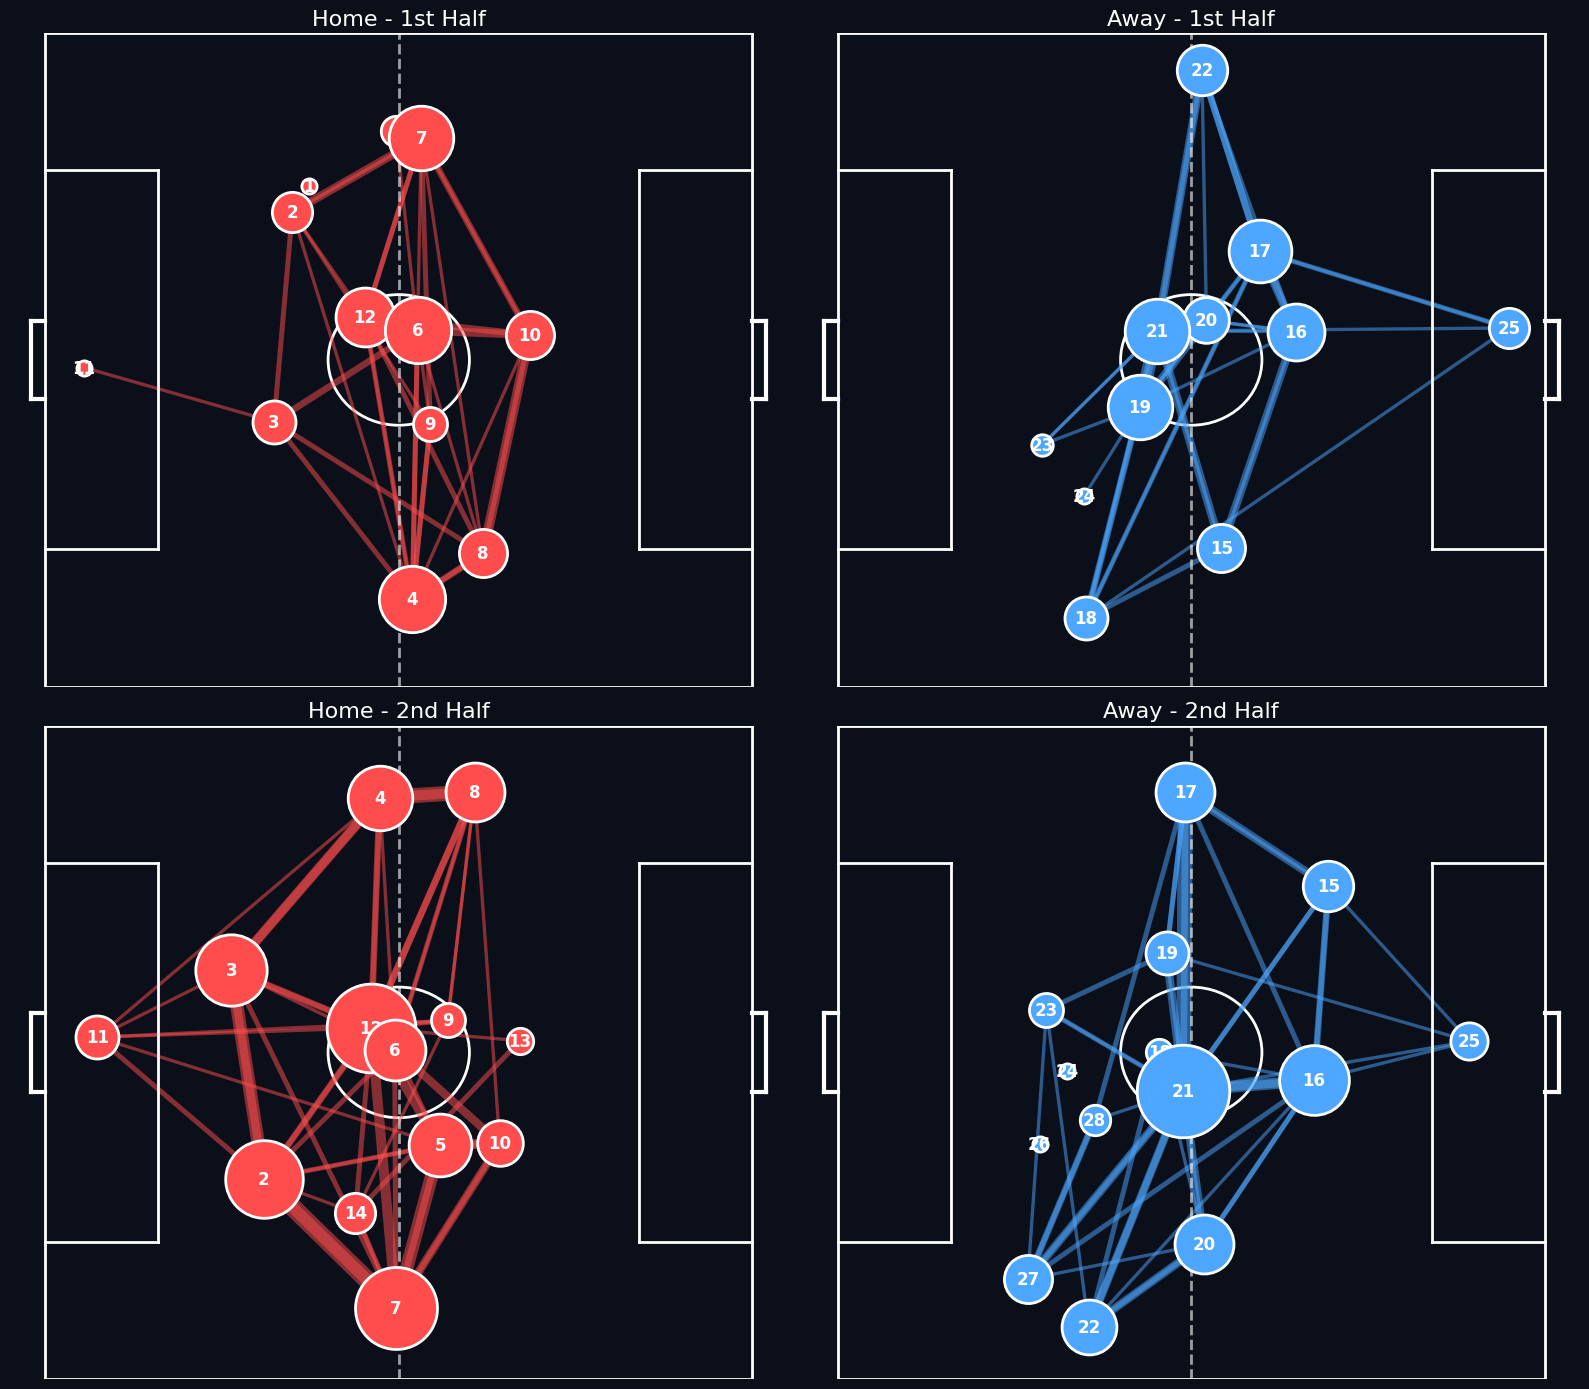

In [400]:
fig, axes = plt.subplots(2, 2, figsize=(16,14), facecolor='#0b0f1a')

plot_network_pro(axes[0,0], home_pos_1h, home_pairs_1h, "Home - 1st Half", "#ff4d4d")
plot_network_pro(axes[0,1], away_pos_1h, away_pairs_1h, "Away - 1st Half", "#4da6ff")

plot_network_pro(axes[1,0], home_pos_2h, home_pairs_2h, "Home - 2nd Half", "#ff4d4d")
plot_network_pro(axes[1,1], away_pos_2h, away_pairs_2h, "Away - 2nd Half", "#4da6ff")

plt.tight_layout()
plt.show()